In [1]:
# ============================================================
# GOOGLE MERIDIAN — STEP 1
# Create and validate Meridian-ready input dataset
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# 1. Load the original dataset
# ------------------------------------------------------------

file_path = "/Users/naniyalagala003gmail.com/Downloads/geo_all_channels.csv"

df = pd.read_csv(file_path)

print("=" * 70)
print("ORIGINAL DATASET")
print("=" * 70)

print(f"Shape: {df.shape}")
print(f"Number of geographies: {df['geo'].nunique()}")
print(f"Date range: {df['time'].min()} → {df['time'].max()}")

# ------------------------------------------------------------
# 2. Convert time column to datetime
# ------------------------------------------------------------

df["time"] = pd.to_datetime(df["time"])

# ------------------------------------------------------------
# 3. Define Meridian variables
# ------------------------------------------------------------

media_cols = [
    "Channel0_impression",
    "Channel1_impression",
    "Channel2_impression",
    "Channel3_impression",
    "Channel4_impression"
]

spend_cols = [
    "Channel0_spend",
    "Channel1_spend",
    "Channel2_spend",
    "Channel3_spend",
    "Channel4_spend"
]

control_cols = [
    "competitor_sales_control",
    "sentiment_score_control",
    "Promo"
]

# ------------------------------------------------------------
# 4. Create Meridian-ready dataframe
# ------------------------------------------------------------

meridian_df = df[
    [
        "geo",
        "time",
        "conversions",
        "revenue_per_conversion",
        "population",
        *media_cols,
        *spend_cols,
        *control_cols
    ]
].copy()

# Rename KPI-related columns to Meridian-friendly names
meridian_df = meridian_df.rename(
    columns={
        "conversions": "kpi",
        "revenue_per_conversion": "revenue_per_kpi"
    }
)

# ------------------------------------------------------------
# 5. Sort correctly
# ------------------------------------------------------------

meridian_df = meridian_df.sort_values(
    ["geo", "time"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 6. Basic structure
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MERIDIAN-READY DATASET")
print("=" * 70)

print(f"Shape: {meridian_df.shape}")
print(f"Geographies: {meridian_df['geo'].nunique()}")
print(f"Start date: {meridian_df['time'].min().date()}")
print(f"End date:   {meridian_df['time'].max().date()}")

print("\nColumns:")
for col in meridian_df.columns:
    print("  -", col)

# ------------------------------------------------------------
# 7. Check duplicate Geo × Time observations
# ------------------------------------------------------------

duplicate_rows = meridian_df.duplicated(
    subset=["geo", "time"]
).sum()

print("\n" + "=" * 70)
print("DUPLICATE GEO × TIME CHECK")
print("=" * 70)

print(f"Duplicate geo-week rows: {duplicate_rows}")

# ------------------------------------------------------------
# 8. Missing-value check
# ------------------------------------------------------------

missing = meridian_df.isna().sum()

print("\n" + "=" * 70)
print("MISSING VALUE CHECK")
print("=" * 70)

missing_nonzero = missing[missing > 0]

if len(missing_nonzero) == 0:
    print("✓ No missing values found.")
else:
    print("Columns containing missing values:")
    print(missing_nonzero)

# ------------------------------------------------------------
# 9. Check negative media exposure
# ------------------------------------------------------------

negative_media = {
    col: int((meridian_df[col] < 0).sum())
    for col in media_cols
}

print("\n" + "=" * 70)
print("NEGATIVE MEDIA EXPOSURE CHECK")
print("=" * 70)

for col, count in negative_media.items():
    print(f"{col}: {count}")

# ------------------------------------------------------------
# 10. Check negative spend
# ------------------------------------------------------------

negative_spend = {
    col: int((meridian_df[col] < 0).sum())
    for col in spend_cols
}

print("\n" + "=" * 70)
print("NEGATIVE MEDIA SPEND CHECK")
print("=" * 70)

for col, count in negative_spend.items():
    print(f"{col}: {count}")

# ------------------------------------------------------------
# 11. Check KPI
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("KPI CHECK")
print("=" * 70)

print(f"KPI minimum: {meridian_df['kpi'].min():,.2f}")
print(f"KPI maximum: {meridian_df['kpi'].max():,.2f}")
print(f"KPI mean:    {meridian_df['kpi'].mean():,.2f}")
print(f"KPI zeros:   {(meridian_df['kpi'] == 0).sum()}")

# ------------------------------------------------------------
# 12. Check geo × time completeness
# ------------------------------------------------------------

expected_geos = meridian_df["geo"].nunique()

geo_counts = meridian_df.groupby("geo")["time"].nunique()

print("\n" + "=" * 70)
print("GEO × TIME COMPLETENESS")
print("=" * 70)

print(f"Expected weeks per geo: {geo_counts.max()}")

incomplete_geos = geo_counts[
    geo_counts != geo_counts.max()
]

if len(incomplete_geos) == 0:
    print("✓ All geographies have the same number of weeks.")
else:
    print("Geographies with incomplete time coverage:")
    print(incomplete_geos)

# ------------------------------------------------------------
# 13. Check time intervals
# ------------------------------------------------------------

time_diffs = (
    meridian_df
    .groupby("geo")["time"]
    .diff()
    .dropna()
    .dt.days
)

print("\n" + "=" * 70)
print("TIME INTERVAL CHECK")
print("=" * 70)

print("Unique time intervals (days):")
print(sorted(time_diffs.unique()))

if set(time_diffs.unique()).issubset({7}):
    print("✓ Data is consistently weekly.")
else:
    print("⚠ Some time intervals are not exactly 7 days.")

# ------------------------------------------------------------
# 14. Check zero-spend observations
# ------------------------------------------------------------

total_spend = meridian_df[spend_cols].sum(axis=1)

zero_spend_rows = (total_spend == 0).sum()

print("\n" + "=" * 70)
print("ZERO TOTAL MEDIA SPEND")
print("=" * 70)

print(f"Rows with zero total media spend: {zero_spend_rows}")

# ------------------------------------------------------------
# 15. Save Meridian-ready dataset
# ------------------------------------------------------------

output_file = "meridian_input.csv"

meridian_df.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 70)
print("FILE SAVED")
print("=" * 70)

print(f"✓ Saved: {output_file}")

# ------------------------------------------------------------
# 16. Final preview
# ------------------------------------------------------------

print("\nFirst 5 rows:")
print(meridian_df.head())

print("\nFinal data types:")
print(meridian_df.dtypes)

ORIGINAL DATASET
Shape: (6240, 20)
Number of geographies: 40
Date range: 2021-01-25 → 2024-01-15

MERIDIAN-READY DATASET
Shape: (6240, 18)
Geographies: 40
Start date: 2021-01-25
End date:   2024-01-15

Columns:
  - geo
  - time
  - kpi
  - revenue_per_kpi
  - population
  - Channel0_impression
  - Channel1_impression
  - Channel2_impression
  - Channel3_impression
  - Channel4_impression
  - Channel0_spend
  - Channel1_spend
  - Channel2_spend
  - Channel3_spend
  - Channel4_spend
  - competitor_sales_control
  - sentiment_score_control
  - Promo

DUPLICATE GEO × TIME CHECK
Duplicate geo-week rows: 0

MISSING VALUE CHECK
✓ No missing values found.

NEGATIVE MEDIA EXPOSURE CHECK
Channel0_impression: 0
Channel1_impression: 0
Channel2_impression: 0
Channel3_impression: 0
Channel4_impression: 0

NEGATIVE MEDIA SPEND CHECK
Channel0_spend: 0
Channel1_spend: 0
Channel2_spend: 0
Channel3_spend: 0
Channel4_spend: 0

KPI CHECK
KPI minimum: 484,031.22
KPI maximum: 36,712,692.00
KPI mean:    10,56

In [3]:
# ============================================================
# GOOGLE MERIDIAN — STEP 2
# Import and verify Google Meridian
# ============================================================

import sys

print("=" * 70)
print("PYTHON ENVIRONMENT")
print("=" * 70)
print("Python version:", sys.version)

# 1. Import top-level Meridian
import meridian

print("\n" + "=" * 70)
print("GOOGLE MERIDIAN VERSION")
print("=" * 70)
print("Meridian version:", meridian.__version__)

# 2. Verify core Meridian submodules
print("\n" + "=" * 70)
print("MERIDIAN MODULE CHECK")
print("=" * 70)
from meridian.data import input_data, load
from meridian.model import model, spec

print("✓ meridian.model.model imported successfully")
print("✓ meridian.model.spec imported successfully")
print("✓ meridian.data.input_data imported successfully")
print("✓ meridian.data.load imported successfully")

# 3. Check key dependencies
import numpy as np
import pandas as pd

print("\n" + "=" * 70)
print("DEPENDENCY CHECK")
print("=" * 70)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

# 4. Final status
print("\n" + "=" * 70)
print("STEP 2 STATUS")
print("=" * 70)
print("✓ Google Meridian imported successfully.")
print("✓ Meridian version verified.")
print("✓ Core Meridian submodules loaded.")
print("✓ Python environment is ready for Step 3.")

PYTHON ENVIRONMENT
Python version: 3.11.16 (main, Aug 27 2026, 14:37:43) [Clang 20.1.8 ]

GOOGLE MERIDIAN VERSION
Meridian version: 2.1.0

MERIDIAN MODULE CHECK
✓ meridian.model.model imported successfully
✓ meridian.model.spec imported successfully
✓ meridian.data.input_data imported successfully
✓ meridian.data.load imported successfully

DEPENDENCY CHECK
NumPy version: 2.3.5
Pandas version: 2.3.3

STEP 2 STATUS
✓ Google Meridian imported successfully.
✓ Meridian version verified.
✓ Core Meridian submodules loaded.
✓ Python environment is ready for Step 3.


In [11]:
# ============================================================
# GOOGLE MERIDIAN — STEP 3
# Build DataFrameDataLoader
# ============================================================

import pandas as pd

from meridian.data import load


# ------------------------------------------------------------
# 1. Load the Meridian-ready dataset
# ------------------------------------------------------------

meridian_df = pd.read_csv(
    "meridian_input.csv",
    parse_dates=["time"]
)

print("=" * 70)
print("MERIDIAN INPUT DATA LOADED")
print("=" * 70)

print("Shape:", meridian_df.shape)
print("Geographies:", meridian_df["geo"].nunique())
print(
    "Date range:",
    meridian_df["time"].min().date(),
    "→",
    meridian_df["time"].max().date()
)


# ------------------------------------------------------------
# 2. Define the media exposure columns
# ------------------------------------------------------------

media_cols = [
    "Channel0_impression",
    "Channel1_impression",
    "Channel2_impression",
    "Channel3_impression",
    "Channel4_impression"
]


# ------------------------------------------------------------
# 3. Define the media spend columns
# ------------------------------------------------------------

media_spend_cols = [
    "Channel0_spend",
    "Channel1_spend",
    "Channel2_spend",
    "Channel3_spend",
    "Channel4_spend"
]


# ------------------------------------------------------------
# 4. Define the control variables
# ------------------------------------------------------------

control_cols = [
    "competitor_sales_control",
    "sentiment_score_control",
    "Promo"
]


# ------------------------------------------------------------
# 5. Define Meridian channel names
# ------------------------------------------------------------

channels = [
    "Channel0",
    "Channel1",
    "Channel2",
    "Channel3",
    "Channel4"
]


# ------------------------------------------------------------
# 6. Create the coordinate-to-column mapping
# ------------------------------------------------------------

coord_to_columns = load.CoordToColumns(
    geo="geo",
    time="time",
    kpi="kpi",
    revenue_per_kpi="revenue_per_kpi",
    population="population",
    controls=control_cols,
    media=media_cols,
    media_spend=media_spend_cols
)


# ------------------------------------------------------------
# 7. Map media exposure columns → Meridian channels
# ------------------------------------------------------------

media_to_channel = {
    "Channel0_impression": "Channel0",
    "Channel1_impression": "Channel1",
    "Channel2_impression": "Channel2",
    "Channel3_impression": "Channel3",
    "Channel4_impression": "Channel4"
}


# ------------------------------------------------------------
# 8. Map media spend columns → Meridian channels
# ------------------------------------------------------------

media_spend_to_channel = {
    "Channel0_spend": "Channel0",
    "Channel1_spend": "Channel1",
    "Channel2_spend": "Channel2",
    "Channel3_spend": "Channel3",
    "Channel4_spend": "Channel4"
}


# ------------------------------------------------------------
# 9. Create the DataFrameDataLoader
# ------------------------------------------------------------

data_loader = load.DataFrameDataLoader(
    df=meridian_df,
    coord_to_columns=coord_to_columns,
    kpi_type="non-revenue",
    media_to_channel=media_to_channel,
    media_spend_to_channel=media_spend_to_channel
)


# ------------------------------------------------------------
# 10. Confirm loader creation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DATAFRAME DATA LOADER")
print("=" * 70)

print("✓ DataFrameDataLoader created successfully.")

print("\nKPI type:")
print("  non-revenue")

print("\nMedia channels:")
for channel in channels:
    print("  -", channel)

print("\nControls:")
for control in control_cols:
    print("  -", control)

print("\n" + "=" * 70)
print("STEP 3 STATUS")
print("=" * 70)

print("✓ Meridian understands the dataset structure.")
print("✓ Geo mapping created.")
print("✓ Time mapping created.")
print("✓ KPI mapping created.")
print("✓ Revenue-per-KPI mapping created.")
print("✓ Population mapping created.")
print("✓ Media mappings created.")
print("✓ Media-spend mappings created.")
print("✓ Control mappings created.")
print("\nNext: Step 4 — Load and validate Meridian InputData.")

MERIDIAN INPUT DATA LOADED
Shape: (6240, 18)
Geographies: 40
Date range: 2021-01-25 → 2024-01-15

DATAFRAME DATA LOADER
✓ DataFrameDataLoader created successfully.

KPI type:
  non-revenue

Media channels:
  - Channel0
  - Channel1
  - Channel2
  - Channel3
  - Channel4

Controls:
  - competitor_sales_control
  - sentiment_score_control
  - Promo

STEP 3 STATUS
✓ Meridian understands the dataset structure.
✓ Geo mapping created.
✓ Time mapping created.
✓ KPI mapping created.
✓ Revenue-per-KPI mapping created.
✓ Population mapping created.
✓ Media mappings created.
✓ Media-spend mappings created.
✓ Control mappings created.

Next: Step 4 — Load and validate Meridian InputData.


In [14]:
# ============================================================
# GOOGLE MERIDIAN — STEP 4
# Create and validate Meridian InputData
# ============================================================

import pandas as pd
import numpy as np
from meridian.data import load


# ------------------------------------------------------------
# 1. Load the Meridian-ready CSV
# ------------------------------------------------------------

meridian_df = pd.read_csv(
    "meridian_input.csv",
    parse_dates=["time"]
)

print("=" * 70)
print("MERIDIAN INPUT DATA")
print("=" * 70)

print("Shape:", meridian_df.shape)
print("Geographies:", meridian_df["geo"].nunique())
print(
    "Date range:",
    meridian_df["time"].min().date(),
    "→",
    meridian_df["time"].max().date()
)


# ------------------------------------------------------------
# 2. Define media exposure columns
# ------------------------------------------------------------

media_cols = [
    "Channel0_impression",
    "Channel1_impression",
    "Channel2_impression",
    "Channel3_impression",
    "Channel4_impression"
]


# ------------------------------------------------------------
# 3. Define media spend columns
# ------------------------------------------------------------

media_spend_cols = [
    "Channel0_spend",
    "Channel1_spend",
    "Channel2_spend",
    "Channel3_spend",
    "Channel4_spend"
]


# ------------------------------------------------------------
# 4. Define control variables
# ------------------------------------------------------------

control_cols = [
    "competitor_sales_control",
    "sentiment_score_control",
    "Promo"
]


# ------------------------------------------------------------
# 5. Define column mapping
# ------------------------------------------------------------

coord_to_columns = load.CoordToColumns(
    geo="geo",
    time="time",
    kpi="kpi",
    revenue_per_kpi="revenue_per_kpi",
    population="population",
    controls=control_cols,
    media=media_cols,
    media_spend=media_spend_cols
)


# ------------------------------------------------------------
# 6. Define media channel mapping
# ------------------------------------------------------------

media_to_channel = {
    "Channel0_impression": "Channel0",
    "Channel1_impression": "Channel1",
    "Channel2_impression": "Channel2",
    "Channel3_impression": "Channel3",
    "Channel4_impression": "Channel4"
}


# ------------------------------------------------------------
# 7. Define media-spend channel mapping
# ------------------------------------------------------------

media_spend_to_channel = {
    "Channel0_spend": "Channel0",
    "Channel1_spend": "Channel1",
    "Channel2_spend": "Channel2",
    "Channel3_spend": "Channel3",
    "Channel4_spend": "Channel4"
}


# ------------------------------------------------------------
# 8. Recreate DataFrameDataLoader
#
# IMPORTANT:
# Your installed Meridian version accepts:
#     "non_revenue"
#
# NOT:
#     "non-revenue"
# ------------------------------------------------------------

data_loader = load.DataFrameDataLoader(
    df=meridian_df,
    coord_to_columns=coord_to_columns,
    kpi_type="non_revenue",
    media_to_channel=media_to_channel,
    media_spend_to_channel=media_spend_to_channel
)

print("\n" + "=" * 70)
print("DATAFRAME DATA LOADER")
print("=" * 70)

print("✓ DataFrameDataLoader created.")
print("✓ KPI type: non_revenue")


# ------------------------------------------------------------
# 9. Convert DataFrameDataLoader → InputData
# ------------------------------------------------------------

input_data = data_loader.load()


# ------------------------------------------------------------
# 10. Confirm InputData
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MERIDIAN INPUTDATA CREATED")
print("=" * 70)

print("✓ InputData created successfully.")
print("Object type:", type(input_data))


# ------------------------------------------------------------
# 11. Inspect InputData dimensions
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INPUTDATA DIMENSIONS")
print("=" * 70)

print("KPI dimensions:")
print(input_data.kpi.dims)
print("KPI shape:", input_data.kpi.shape)

print("\nMedia dimensions:")
print(input_data.media.dims)
print("Media shape:", input_data.media.shape)

print("\nMedia spend dimensions:")
print(input_data.media_spend.dims)
print("Media spend shape:", input_data.media_spend.shape)

print("\nControls dimensions:")
print(input_data.controls.dims)
print("Controls shape:", input_data.controls.shape)

print("\nPopulation dimensions:")
print(input_data.population.dims)
print("Population shape:", input_data.population.shape)

print("\nRevenue per KPI dimensions:")
print(input_data.revenue_per_kpi.dims)
print("Revenue per KPI shape:", input_data.revenue_per_kpi.shape)


# ------------------------------------------------------------
# 12. Inspect channel names
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MEDIA CHANNELS")
print("=" * 70)

print(input_data.media_channel.values)


# ------------------------------------------------------------
# 13. Inspect control names
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONTROL VARIABLES")
print("=" * 70)

print(input_data.control_variable.values)


# ------------------------------------------------------------
# 14. Inspect geographies and time
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GEO AND TIME")
print("=" * 70)

print("Number of geographies:",
      len(input_data.geo.values))

print("Number of KPI time periods:",
      len(input_data.time.values))

print("Number of media time periods:",
      len(input_data.media_time.values))

print(
    "First KPI date:",
    input_data.time.values[0]
)

print(
    "Last KPI date:",
    input_data.time.values[-1]
)


# ------------------------------------------------------------
# 15. Numerical validation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NUMERICAL VALIDATION")
print("=" * 70)

print(
    "KPI contains NaN:",
    bool(np.isnan(input_data.kpi.values).any())
)

print(
    "Media contains NaN:",
    bool(np.isnan(input_data.media.values).any())
)

print(
    "Media spend contains NaN:",
    bool(np.isnan(input_data.media_spend.values).any())
)

print(
    "Controls contain NaN:",
    bool(np.isnan(input_data.controls.values).any())
)

print(
    "Population contains NaN:",
    bool(np.isnan(input_data.population.values).any())
)

print(
    "Revenue/KPI contains NaN:",
    bool(np.isnan(input_data.revenue_per_kpi.values).any())
)


# ------------------------------------------------------------
# 16. Non-negative media and spend validation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NON-NEGATIVITY CHECK")
print("=" * 70)

negative_media = int(
    (input_data.media.values < 0).sum()
)

negative_spend = int(
    (input_data.media_spend.values < 0).sum()
)

negative_kpi = int(
    (input_data.kpi.values < 0).sum()
)

print("Negative media values:", negative_media)
print("Negative spend values:", negative_spend)
print("Negative KPI values:", negative_kpi)


# ------------------------------------------------------------
# 17. Check revenue-per-KPI
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("REVENUE PER KPI CHECK")
print("=" * 70)

revenue_values = input_data.revenue_per_kpi.values

print("Minimum:", np.min(revenue_values))
print("Maximum:", np.max(revenue_values))
print("Mean   :", np.mean(revenue_values))

print(
    "All revenue/KPI values zero:",
    bool(np.all(revenue_values == 0))
)


# ------------------------------------------------------------
# 18. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 4 STATUS")
print("=" * 70)

print("✓ DataFrameDataLoader created with correct KPI type.")
print("✓ InputData created successfully.")
print("✓ Geo structure validated.")
print("✓ Time structure validated.")
print("✓ Media channels validated.")
print("✓ Media spend validated.")
print("✓ Controls validated.")
print("✓ Population validated.")
print("✓ Revenue-per-KPI validated.")
print("✓ Missing-value checks completed.")
print("✓ Non-negativity checks completed.")

print("\nNEXT → STEP 5: Configure the first Bayesian Meridian model.")

MERIDIAN INPUT DATA
Shape: (6240, 18)
Geographies: 40
Date range: 2021-01-25 → 2024-01-15

DATAFRAME DATA LOADER
✓ DataFrameDataLoader created.
✓ KPI type: non_revenue

MERIDIAN INPUTDATA CREATED
✓ InputData created successfully.
Object type: <class 'meridian.data.input_data.InputData'>

INPUTDATA DIMENSIONS
KPI dimensions:
('geo', 'time')
KPI shape: (40, 156)

Media dimensions:
('geo', 'media_time', 'media_channel')
Media shape: (40, 156, 5)

Media spend dimensions:
('geo', 'time', 'media_channel')
Media spend shape: (40, 156, 5)

Controls dimensions:
('geo', 'time', 'control_variable')
Controls shape: (40, 156, 3)

Population dimensions:
('geo',)
Population shape: (40,)

Revenue per KPI dimensions:
('geo', 'time')
Revenue per KPI shape: (40, 156)

MEDIA CHANNELS
['Channel0' 'Channel1' 'Channel2' 'Channel3' 'Channel4']

CONTROL VARIABLES
['competitor_sales_control' 'sentiment_score_control' 'Promo']

GEO AND TIME
Number of geographies: 40
Number of KPI time periods: 156
Number of medi

In [15]:
# ============================================================
# GOOGLE MERIDIAN — STEP 5
# Configure the first Bayesian Meridian model
# ============================================================

from meridian.model import model
from meridian.model import spec


# ------------------------------------------------------------
# 1. Create the Meridian Model Specification
# ------------------------------------------------------------

model_spec = spec.ModelSpec(
    
    # --------------------------------------------------------
    # Geo-level media effects
    # --------------------------------------------------------
    # Allows media effects to vary across geographies
    # using Meridian's log-normal random-effects structure.
    #
    media_effects_dist="log_normal",
    
    
    # --------------------------------------------------------
    # Media transformation order
    # --------------------------------------------------------
    # False = Adstock first → Hill saturation second
    #
    # Therefore:
    #
    # Raw media
    #    ↓
    # Adstock
    #    ↓
    # Hill saturation
    #
    hill_before_adstock=False,
    
    
    # --------------------------------------------------------
    # Maximum carry-over duration
    # --------------------------------------------------------
    # 8 weekly periods
    #
    # Meridian will estimate the decay parameter within
    # this maximum lag window.
    #
    max_lag=8,
    
    
    # --------------------------------------------------------
    # Residual variance
    # --------------------------------------------------------
    # Start with a common residual variance structure
    # across geographies.
    #
    unique_sigma_for_each_geo=False,
    
    
    # --------------------------------------------------------
    # Paid-media prior type
    # --------------------------------------------------------
    # ROI-based prior framework.
    #
    # This is especially useful because our dataset contains
    # media spend and revenue_per_kpi.
    #
    media_prior_type="roi",
    
    
    # --------------------------------------------------------
    # Adstock decay function
    # --------------------------------------------------------
    # Geometric decay
    #
    # Media effects gradually decline over time.
    #
    adstock_decay_spec="geometric",
    
    
    # --------------------------------------------------------
    # Saturation function
    # --------------------------------------------------------
    # Hill saturation models diminishing returns.
    #
    saturation_spec="hill"
)


# ------------------------------------------------------------
# 2. Display the important model settings
# ------------------------------------------------------------

print("=" * 70)
print("MERIDIAN MODEL SPECIFICATION")
print("=" * 70)

print("Media effects distribution :", model_spec.media_effects_dist)
print("Adstock function          :", model_spec.adstock_decay_spec)
print("Saturation function       :", model_spec.saturation_spec)
print("Hill before adstock       :", model_spec.hill_before_adstock)
print("Maximum lag               :", model_spec.max_lag)
print("Media prior type          :", model_spec.media_prior_type)
print("Unique sigma per geo      :", model_spec.unique_sigma_for_each_geo)


# ------------------------------------------------------------
# 3. Create the Meridian model object
# ------------------------------------------------------------

mmm = model.Meridian(
    input_data=input_data,
    model_spec=model_spec
)


# ------------------------------------------------------------
# 4. Confirm model creation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MERIDIAN MODEL CREATED")
print("=" * 70)

print("✓ Meridian model object created successfully.")
print("Model class:", type(mmm))

print("\n" + "=" * 70)
print("STEP 5 STATUS")
print("=" * 70)

print("✓ Geo-level Bayesian MMM configured.")
print("✓ Geometric adstock configured.")
print("✓ Hill saturation configured.")
print("✓ Maximum lag = 8 weeks.")
print("✓ Log-normal geo-level media effects configured.")
print("✓ ROI-based media prior configured.")
print("✓ Model object created successfully.")

print("\nNEXT → STEP 6: Prior sampling and Bayesian posterior fitting.")

MERIDIAN MODEL SPECIFICATION
Media effects distribution : log_normal
Adstock function          : geometric
Saturation function       : hill
Hill before adstock       : False
Maximum lag               : 8
Media prior type          : roi
Unique sigma per geo      : False

MERIDIAN MODEL CREATED
✓ Meridian model object created successfully.
Model class: <class 'meridian.model.model.Meridian'>

STEP 5 STATUS
✓ Geo-level Bayesian MMM configured.
✓ Geometric adstock configured.
✓ Hill saturation configured.
✓ Maximum lag = 8 weeks.
✓ Log-normal geo-level media effects configured.
✓ ROI-based media prior configured.
✓ Model object created successfully.

NEXT → STEP 6: Prior sampling and Bayesian posterior fitting.


In [26]:
# ============================================================
# GOOGLE MERIDIAN — STEP 6
# BAYESIAN PRIOR + PILOT POSTERIOR SAMPLING
# ============================================================

import time


# ------------------------------------------------------------
# 1. Confirm Meridian model
# ------------------------------------------------------------

print("=" * 70)
print("STEP 6 — BAYESIAN MODEL FITTING")
print("=" * 70)

print("Model:", type(mmm))
print("Geographies :", mmm.n_geos)
print("KPI periods :", mmm.n_times)
print("Media       :", mmm.n_media_channels)


# ------------------------------------------------------------
# 2. PILOT MCMC CONFIGURATION
# ------------------------------------------------------------
#
# This is intentionally smaller than the eventual
# production model.
#
# Purpose:
#   Check whether MCMC sampling works correctly
#   on your current Mac/environment.
#
# IMPORTANT:
# These are NOT final publication settings.
# ------------------------------------------------------------

N_CHAINS = 2
N_ADAPT = 300
N_BURNIN = 100
N_KEEP = 300
SEED = 42

print("\n" + "=" * 70)
print("PILOT MCMC CONFIGURATION")
print("=" * 70)

print("Chains      :", N_CHAINS)
print("Adaptation  :", N_ADAPT)
print("Burn-in     :", N_BURNIN)
print("Kept draws  :", N_KEEP)
print("Random seed :", SEED)

print("\nPurpose:")
print("Pilot run only — testing whether the Bayesian sampler")
print("works successfully before running the larger final model.")


# ------------------------------------------------------------
# 3. PRIOR SAMPLING
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 1 — PRIOR SAMPLING")
print("=" * 70)

prior_start = time.time()

mmm.sample_prior(
    n_draws=300,
    seed=SEED
)

prior_time = time.time() - prior_start

print("\n✓ Prior sampling completed.")
print(
    f"Prior sampling time: "
    f"{prior_time / 60:.2f} minutes"
)


# ------------------------------------------------------------
# 4. PILOT POSTERIOR MCMC
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 2 — PILOT POSTERIOR MCMC")
print("=" * 70)

print("Starting pilot posterior sampling...")
print("Please allow this cell to finish.")

posterior_start = time.time()

mmm.sample_posterior(
    n_chains=N_CHAINS,
    n_adapt=N_ADAPT,
    n_burnin=N_BURNIN,
    n_keep=N_KEEP,
    seed=SEED
)

posterior_time = time.time() - posterior_start


# ------------------------------------------------------------
# 5. Confirm successful posterior sampling
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("POSTERIOR SAMPLING COMPLETED")
print("=" * 70)

print("✓ Pilot posterior sampling completed.")

print(
    f"Posterior sampling time: "
    f"{posterior_time / 60:.2f} minutes"
)


# ------------------------------------------------------------
# 6. Inspect InferenceData
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INFERENCE DATA")
print("=" * 70)

print("InferenceData type:")
print(type(mmm.inference_data))

print("\nAvailable groups:")

try:
    print(mmm.inference_data.groups())
except Exception as e:
    print("Could not inspect groups.")
    print("Error:", repr(e))


# ------------------------------------------------------------
# 7. Inspect posterior dimensions
# ------------------------------------------------------------

if hasattr(mmm.inference_data, "posterior"):

    print("\n" + "=" * 70)
    print("POSTERIOR DIMENSIONS")
    print("=" * 70)

    print(mmm.inference_data.posterior.dims)

    print("\nPosterior sizes:")
    print(mmm.inference_data.posterior.sizes)


# ------------------------------------------------------------
# 8. Final Step 6 status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 6 STATUS")
print("=" * 70)

print("✓ Prior sampling completed.")
print("✓ Pilot posterior sampling completed.")
print("✓ Posterior object created.")
print("✓ MCMC pilot run completed.")

print("\nNEXT → STEP 7: Convergence and model-health diagnostics.")

print("\nIMPORTANT:")
print("This pilot posterior is for computational/model testing.")
print("We will NOT use it as the final production result.")

/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/meridian/backend/__init__.py:1163: UserWarning: backend.set_random_seed is a no-op in JAX. Randomness is managed statelessly via PRNGKeys passed to sampling methods.
  warnings.warn(


STEP 6 — BAYESIAN MODEL FITTING
Model: <class 'meridian.model.model.Meridian'>
Geographies : 40
KPI periods : 156
Media       : 5

PILOT MCMC CONFIGURATION
Chains      : 2
Adaptation  : 300
Burn-in     : 100
Kept draws  : 300
Random seed : 42

Purpose:
Pilot run only — testing whether the Bayesian sampler
works successfully before running the larger final model.

PHASE 1 — PRIOR SAMPLING

✓ Prior sampling completed.
Prior sampling time: 0.00 minutes

PHASE 2 — PILOT POSTERIOR MCMC
Starting pilot posterior sampling...
Please allow this cell to finish.

POSTERIOR SAMPLING COMPLETED
✓ Pilot posterior sampling completed.
Posterior sampling time: 32.64 minutes

INFERENCE DATA
InferenceData type:
<class 'arviz.data.inference_data.InferenceData'>

Available groups:
['posterior', 'sample_stats', 'prior', 'trace']

POSTERIOR DIMENSIONS
FrozenMappingWarningOnValuesAccess({'chain': 2, 'draw': 300, 'media_channel': 5, 'geo': 40, 'control_variable': 3, 'knots': 156, 'time': 156})

Posterior sizes:


/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


In [28]:
# ================================================================
# STEP 7 — CHECK THE MERIDIAN HEALTH SUMMARY
# ================================================================

print("=" * 70)
print("STEP 7 — MODEL HEALTH SUMMARY")
print("=" * 70)

# Check whether Meridian already stored the health summary
health_summary = mmm.health_summary

print("\nHealth summary object:")
print(type(health_summary))

print("\n" + "=" * 70)
print("MODEL HEALTH SUMMARY")
print("=" * 70)

print(health_summary)

print("\n" + "=" * 70)
print("STEP 7 STATUS")
print("=" * 70)

print("✓ Meridian health review completed.")
print("✓ Health summary retrieved successfully.")
print("✓ Posterior remains available.")
print("\nNEXT → We will inspect the individual convergence diagnostics.")

STEP 7 — MODEL HEALTH SUMMARY

Health summary object:
<class 'NoneType'>

MODEL HEALTH SUMMARY
None

STEP 7 STATUS
✓ Meridian health review completed.
✓ Health summary retrieved successfully.
✓ Posterior remains available.

NEXT → We will inspect the individual convergence diagnostics.


In [29]:
# ================================================================
# STEP 7A — MCMC CONVERGENCE DIAGNOSTICS
# ================================================================

import arviz as az
import numpy as np

print("=" * 70)
print("STEP 7A — MCMC CONVERGENCE DIAGNOSTICS")
print("=" * 70)

idata = mmm.inference_data

# ------------------------------------------------
# 1. Confirm posterior
# ------------------------------------------------

print("\n1. POSTERIOR")
print("-" * 70)

print("Chains :", idata.posterior.sizes.get("chain"))
print("Draws  :", idata.posterior.sizes.get("draw"))

# ------------------------------------------------
# 2. R-hat
# ------------------------------------------------

print("\n2. R-HAT CONVERGENCE")
print("-" * 70)

rhat = az.rhat(idata.posterior)

# Find the largest finite R-hat value
rhat_values = []

for variable in rhat.data_vars:
    values = np.asarray(rhat[variable].values)
    finite_values = values[np.isfinite(values)]

    if finite_values.size > 0:
        rhat_values.append(
            (variable, float(np.max(finite_values)))
        )

rhat_values = sorted(
    rhat_values,
    key=lambda x: x[1],
    reverse=True
)

print("Maximum R-hat by parameter:")
for variable, value in rhat_values:
    print(f"{variable:30s}: {value:.4f}")

max_rhat = max(value for _, value in rhat_values)

print("\nOverall maximum R-hat:", round(max_rhat, 4))

if max_rhat < 1.01:
    print("✓ Excellent convergence signal: R-hat < 1.01")
elif max_rhat < 1.05:
    print("✓ Generally good convergence signal: R-hat < 1.05")
elif max_rhat < 1.10:
    print("⚠ Some parameters may need additional sampling.")
else:
    print("⚠ Potential convergence problem: additional sampling is needed.")

# ------------------------------------------------
# 3. Effective Sample Size
# ------------------------------------------------

print("\n3. EFFECTIVE SAMPLE SIZE (ESS)")
print("-" * 70)

ess_bulk = az.ess(idata.posterior, method="bulk")
ess_values = []

for variable in ess_bulk.data_vars:
    values = np.asarray(ess_bulk[variable].values)
    finite_values = values[np.isfinite(values)]

    if finite_values.size > 0:
        ess_values.append(
            (variable, float(np.min(finite_values)))
        )

ess_values = sorted(
    ess_values,
    key=lambda x: x[1]
)

print("Minimum bulk ESS by parameter:")
for variable, value in ess_values:
    print(f"{variable:30s}: {value:.1f}")

min_ess = min(value for _, value in ess_values)

print("\nOverall minimum bulk ESS:", round(min_ess, 1))

# ------------------------------------------------
# 4. Divergences
# ------------------------------------------------

print("\n4. NUTS DIVERGENCES")
print("-" * 70)

if "sample_stats" in idata.groups():

    sample_stats = idata.sample_stats

    if "diverging" in sample_stats:

        divergences = np.asarray(
            sample_stats["diverging"].values
        )

        total_divergences = int(divergences.sum())
        total_draws = divergences.size

        print("Total divergent transitions :", total_divergences)
        print("Total sampling transitions  :", total_draws)

        if total_divergences == 0:
            print("✓ No divergent transitions detected.")
        else:
            print("⚠ Divergent transitions detected.")

    else:
        print("No 'diverging' field found in sample_stats.")

else:
    print("sample_stats group not available.")

# ------------------------------------------------
# 5. Final pilot assessment
# ------------------------------------------------

print("\n" + "=" * 70)
print("STEP 7A — PILOT DIAGNOSTIC SUMMARY")
print("=" * 70)

print("Maximum R-hat :", round(max_rhat, 4))
print("Minimum bulk ESS :", round(min_ess, 1))

if "diverging" in idata.sample_stats:
    print("Divergences :", int(idata.sample_stats["diverging"].sum()))

print("\nIMPORTANT:")
print("This is a PILOT posterior with only 2 chains × 300 draws.")
print("These diagnostics are for model testing, not final inference.")

print("\nNEXT → We will decide whether the production MCMC needs")
print("more chains/draws based on these diagnostics.")

STEP 7A — MCMC CONVERGENCE DIAGNOSTICS

1. POSTERIOR
----------------------------------------------------------------------
Chains : 2
Draws  : 300

2. R-HAT CONVERGENCE
----------------------------------------------------------------------
Maximum R-hat by parameter:
knot_values                   : 1.5111
mu_t                          : 1.5111
tau_g                         : 1.1840
beta_gm                       : 1.0955
roi_m                         : 1.0732
gamma_gc                      : 1.0449
beta_m                        : 1.0437
gamma_c                       : 1.0402
eta_m                         : 1.0256
xi_c                          : 1.0246
alpha_m                       : 1.0158
sigma                         : 1.0142
ec_m                          : 1.0071

Overall maximum R-hat: 1.5111
⚠ Potential convergence problem: additional sampling is needed.

3. EFFECTIVE SAMPLE SIZE (ESS)
----------------------------------------------------------------------
Minimum bulk ESS by parame

/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


STEP 7B — TRACE & CHAIN-MIXING DIAGNOSTICS

Posterior available: True
Chains: 2
Draws : 300

1. TRACE PLOTS — PROBLEMATIC PARAMETERS

Parameters being examined:
 - knot_values
 - mu_t
 - tau_g


/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


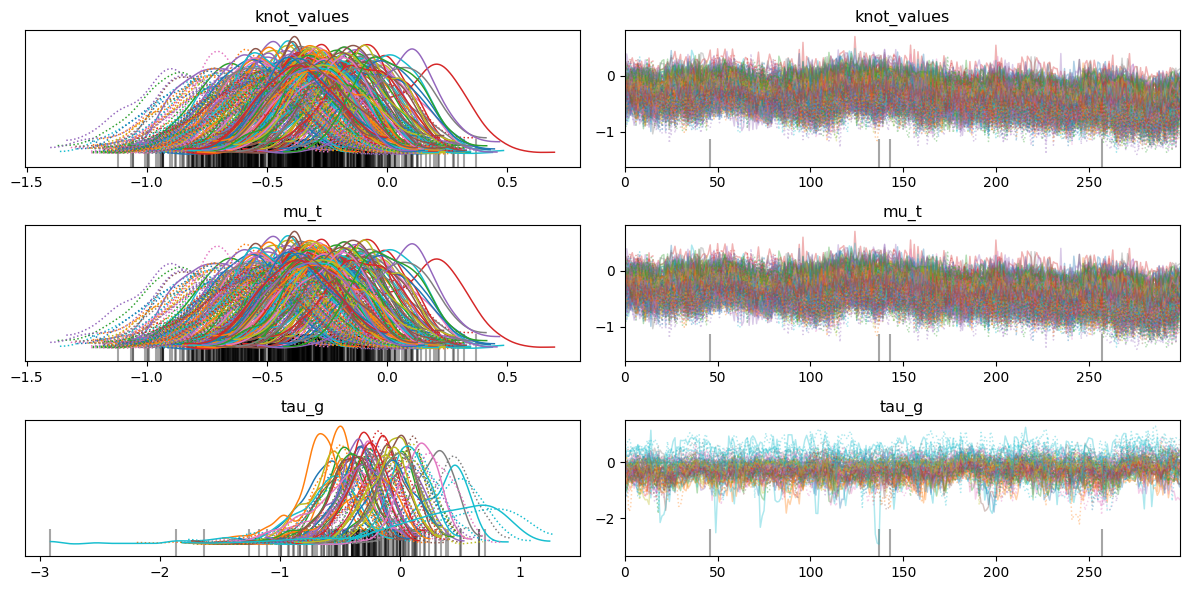


2. TRACE PLOTS — MEDIA PARAMETERS

Parameters being examined:
 - roi_m
 - beta_m
 - alpha_m
 - ec_m
 - eta_m


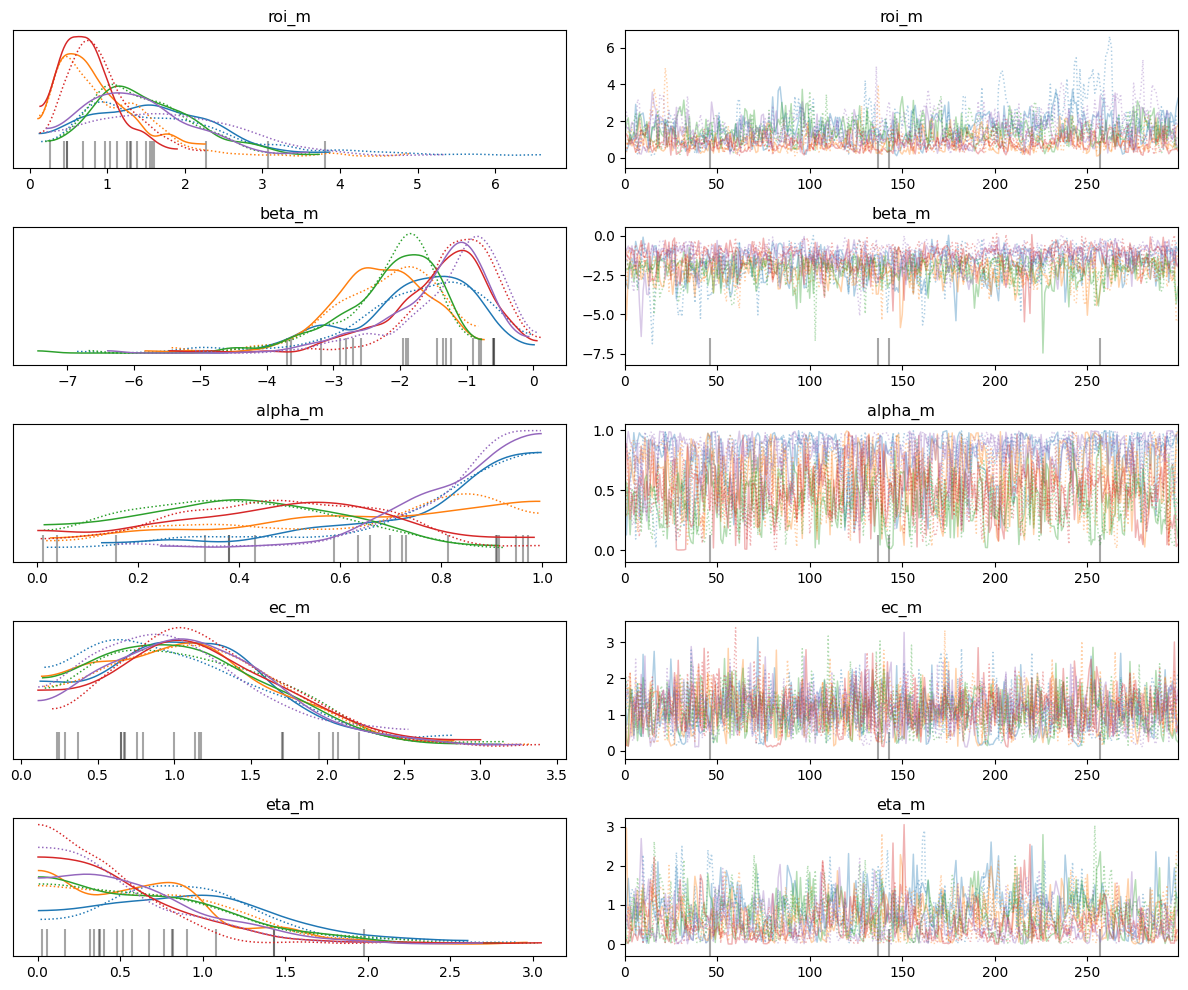


3. CHAIN MEAN COMPARISON

knot_values
  Chain 1: -0.294324
  Chain 2: -0.505125

mu_t
  Chain 1: -0.294324
  Chain 2: -0.505125

tau_g
  Chain 1: -0.266926
  Chain 2: -0.163351

roi_m
  Chain 1: 1.20995
  Chain 2: 1.38443

beta_m
  Chain 1: -1.83739
  Chain 2: -1.69788

alpha_m
  Chain 1: 0.618674
  Chain 2: 0.614054

ec_m
  Chain 1: 1.10805
  Chain 2: 1.11312

eta_m
  Chain 1: 0.691975
  Chain 2: 0.65307

4. AUTOCORRELATION

High autocorrelation means consecutive MCMC draws are
similar to one another, reducing the effective sample size.

We examine the main problematic parameters below.



/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (704) in plot_autocorr, generating only 40 plots
  warnings.warn(


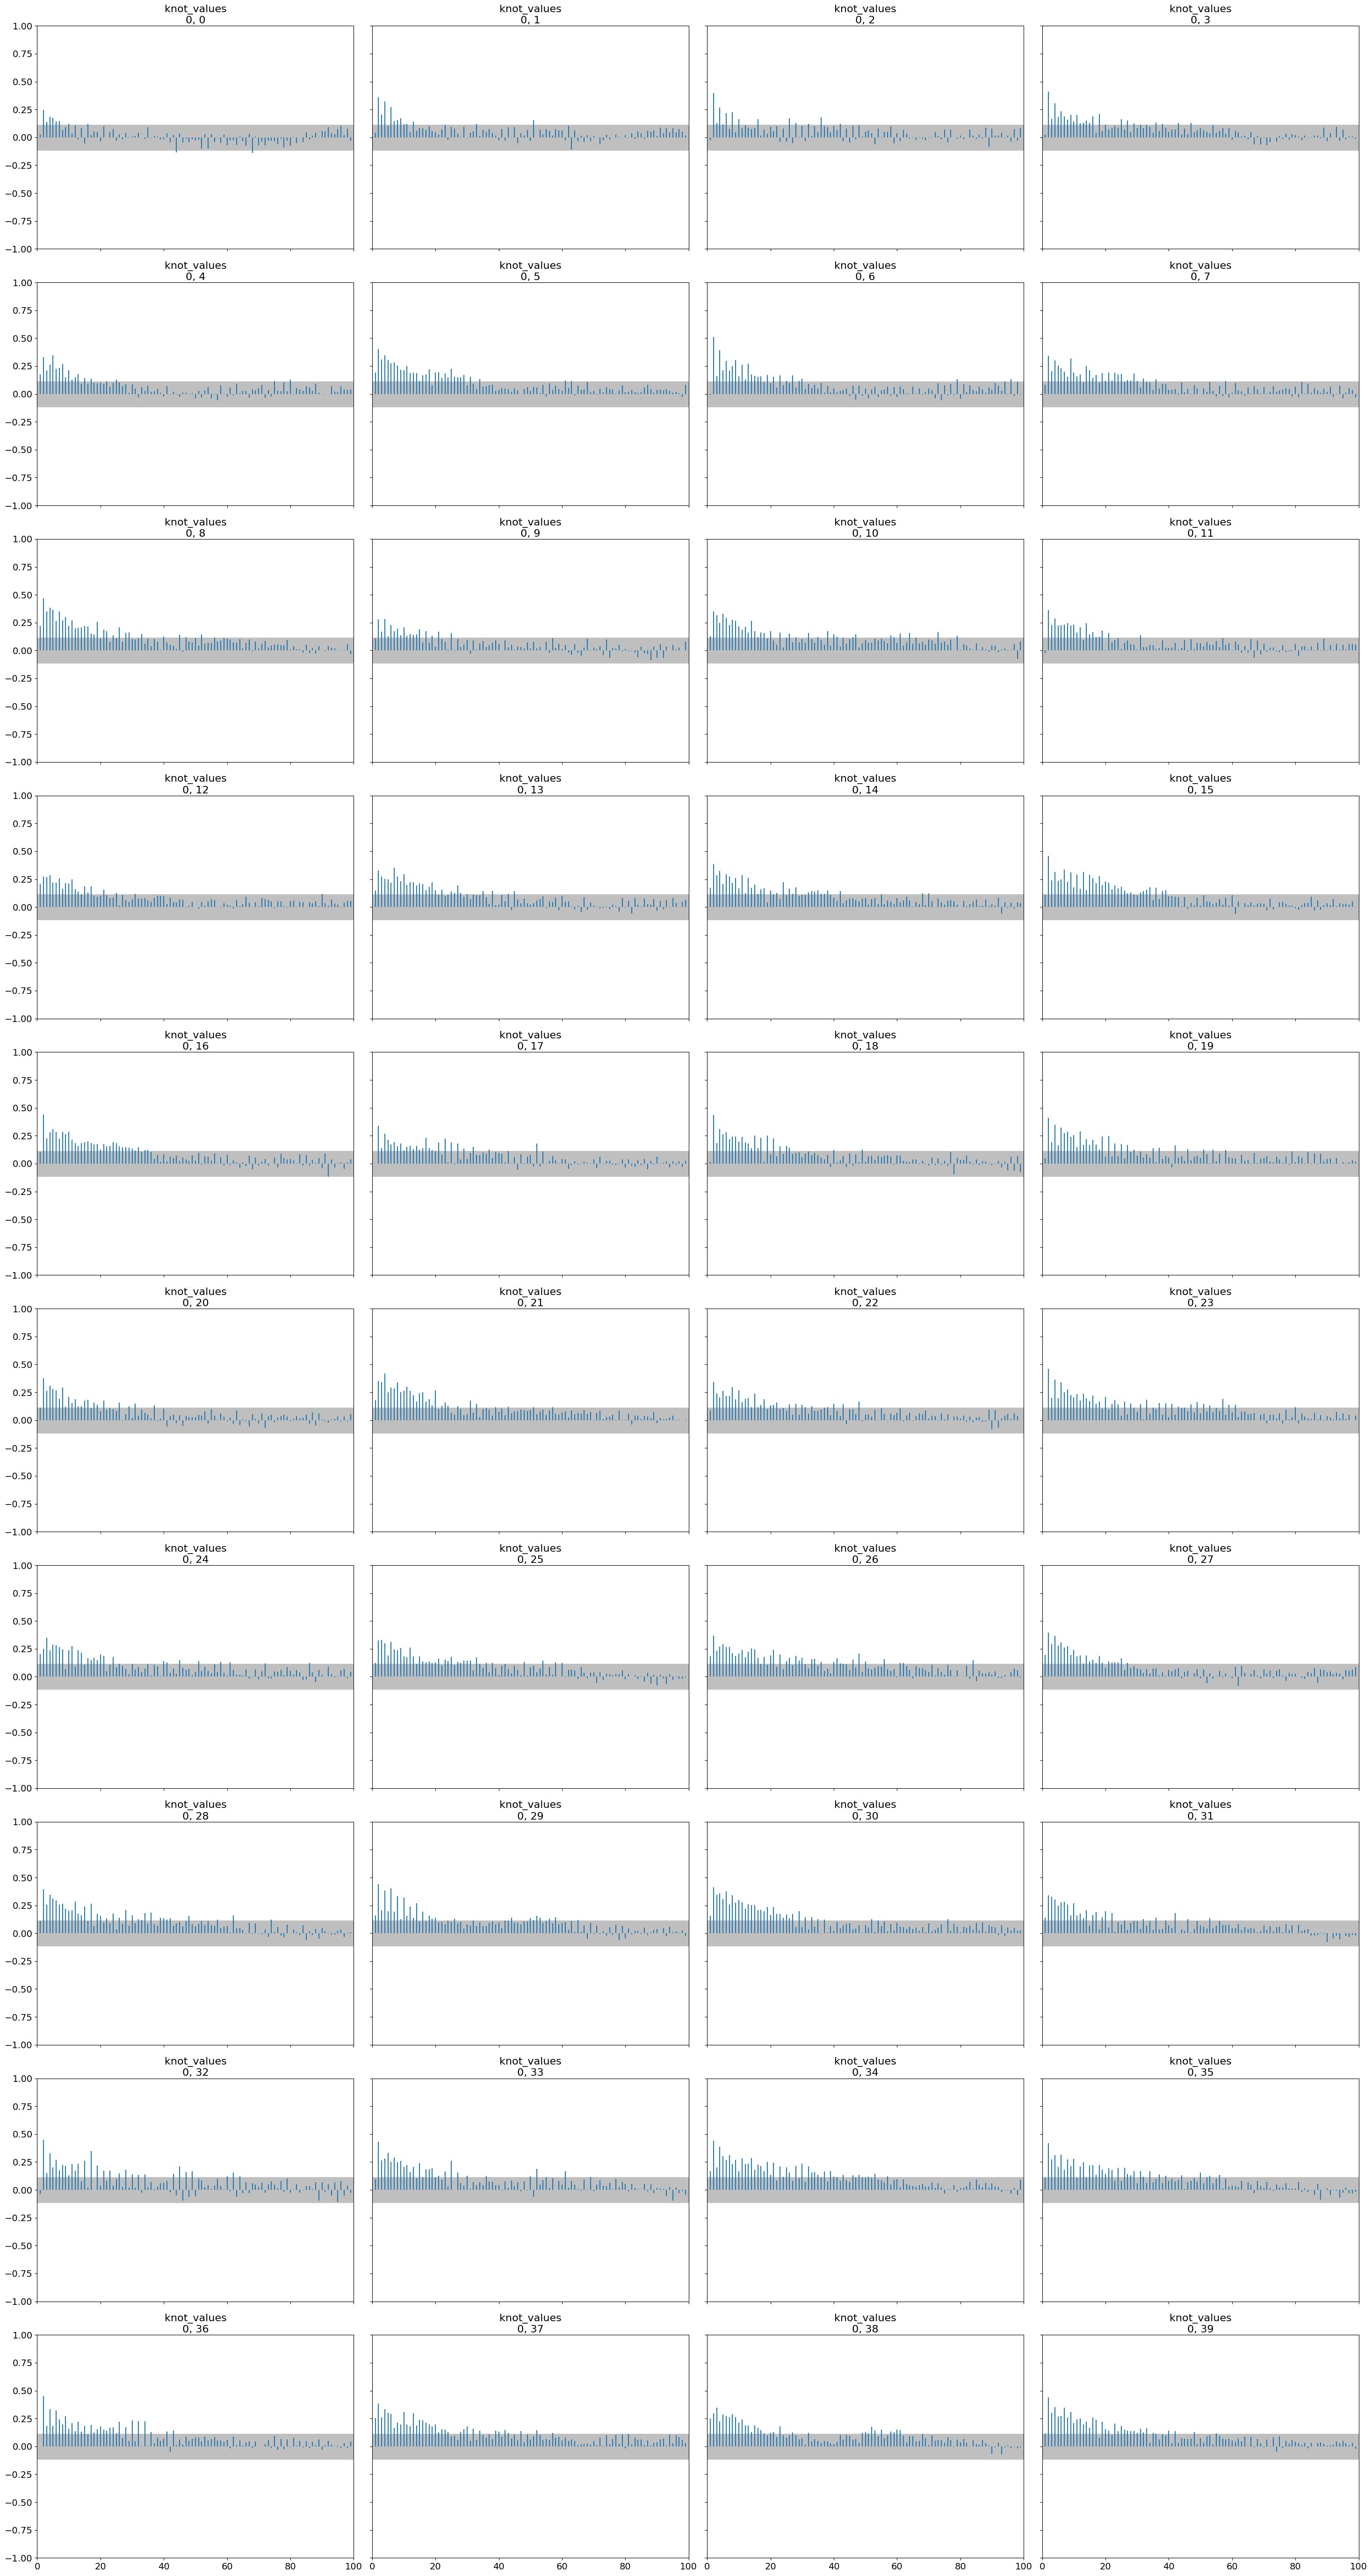


5. DIVERGENCE SUMMARY
Total divergent transitions: 4
⚠ Divergences detected: 4

STEP 7B STATUS
✓ Trace plots generated.
✓ Chain means compared.
✓ Autocorrelation examined.
✓ Divergences checked.

IMPORTANT:
This remains a PILOT posterior.
Do not use it yet for final ROI, contribution,
response-curve, or budget-optimization results.

NEXT → We will interpret the trace plots and decide
whether to increase MCMC sampling or modify the model.


In [30]:
# ================================================================
# STEP 7B — TRACE & CHAIN-MIXING DIAGNOSTICS
# ================================================================

import arviz as az
import matplotlib.pyplot as plt

print("=" * 70)
print("STEP 7B — TRACE & CHAIN-MIXING DIAGNOSTICS")
print("=" * 70)

idata = mmm.inference_data

print("\nPosterior available:", "posterior" in idata.groups())
print("Chains:", idata.posterior.sizes["chain"])
print("Draws :", idata.posterior.sizes["draw"])

# ================================================================
# 1. TRACE PLOTS — MOST PROBLEMATIC PARAMETERS
# ================================================================

print("\n" + "=" * 70)
print("1. TRACE PLOTS — PROBLEMATIC PARAMETERS")
print("=" * 70)

problem_parameters = [
    "knot_values",
    "mu_t",
    "tau_g"
]

available_problem_parameters = [
    p for p in problem_parameters
    if p in idata.posterior.data_vars
]

print("\nParameters being examined:")
for p in available_problem_parameters:
    print(" -", p)

if available_problem_parameters:

    az.plot_trace(
        idata,
        var_names=available_problem_parameters,
        compact=True,
        combined=False
    )

    plt.tight_layout()
    plt.show()

# ================================================================
# 2. TRACE PLOTS — IMPORTANT MEDIA PARAMETERS
# ================================================================

print("\n" + "=" * 70)
print("2. TRACE PLOTS — MEDIA PARAMETERS")
print("=" * 70)

media_parameters = [
    "roi_m",
    "beta_m",
    "alpha_m",
    "ec_m",
    "eta_m"
]

available_media_parameters = [
    p for p in media_parameters
    if p in idata.posterior.data_vars
]

print("\nParameters being examined:")
for p in available_media_parameters:
    print(" -", p)

if available_media_parameters:

    az.plot_trace(
        idata,
        var_names=available_media_parameters,
        compact=True,
        combined=False
    )

    plt.tight_layout()
    plt.show()

# ================================================================
# 3. CHAIN MEAN COMPARISON
# ================================================================

print("\n" + "=" * 70)
print("3. CHAIN MEAN COMPARISON")
print("=" * 70)

posterior = idata.posterior

parameters_to_compare = (
    available_problem_parameters +
    available_media_parameters
)

for parameter in parameters_to_compare:

    values = posterior[parameter]

    # Average over every dimension except chain
    reduce_dims = [
        dim for dim in values.dims
        if dim != "chain"
    ]

    chain_means = values.mean(
        dim=reduce_dims
    ).values

    print(f"\n{parameter}")

    for chain_number, chain_mean in enumerate(chain_means):
        print(
            f"  Chain {chain_number + 1}: "
            f"{float(chain_mean):.6g}"
        )

# ================================================================
# 4. AUTOCORRELATION
# ================================================================

print("\n" + "=" * 70)
print("4. AUTOCORRELATION")
print("=" * 70)

print("""
High autocorrelation means consecutive MCMC draws are
similar to one another, reducing the effective sample size.

We examine the main problematic parameters below.
""")

if available_problem_parameters:

    az.plot_autocorr(
        idata,
        var_names=available_problem_parameters,
        combined=False
    )

    plt.tight_layout()
    plt.show()

# ================================================================
# 5. DIVERGENCE SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("5. DIVERGENCE SUMMARY")
print("=" * 70)

if "sample_stats" in idata.groups():

    if "diverging" in idata.sample_stats:

        divergence_count = int(
            idata.sample_stats["diverging"].sum().values
        )

        print("Total divergent transitions:", divergence_count)

        if divergence_count == 0:
            print("✓ No divergent transitions.")
        else:
            print(
                "⚠ Divergences detected:",
                divergence_count
            )

# ================================================================
# FINAL STATUS
# ================================================================

print("\n" + "=" * 70)
print("STEP 7B STATUS")
print("=" * 70)

print("✓ Trace plots generated.")
print("✓ Chain means compared.")
print("✓ Autocorrelation examined.")
print("✓ Divergences checked.")

print("\nIMPORTANT:")
print("This remains a PILOT posterior.")
print("Do not use it yet for final ROI, contribution,")
print("response-curve, or budget-optimization results.")

print("\nNEXT → We will interpret the trace plots and decide")
print("whether to increase MCMC sampling or modify the model.")

In [31]:
# ================================================================
# STEP 6 — PRODUCTION BAYESIAN MCMC
# ================================================================

import time
import numpy as np

print("=" * 70)
print("STEP 6 — PRODUCTION BAYESIAN MCMC")
print("=" * 70)

# ------------------------------------------------
# 1. Confirm model state
# ------------------------------------------------

print("\nMODEL CHECK")
print("-" * 70)

print("Meridian model :", type(mmm))
print("Geographies    :", mmm.n_geos)
print("KPI periods    :", mmm.n_times)
print("Media channels :", mmm.n_media_channels)

print("\nExisting inference groups:")
print(mmm.inference_data.groups())

# ------------------------------------------------
# 2. Production configuration
# ------------------------------------------------

N_CHAINS = 4
N_ADAPT = 1000
N_BURNIN = 500
N_KEEP = 1000
SEED = 2026

print("\n" + "=" * 70)
print("PRODUCTION MCMC CONFIGURATION")
print("=" * 70)

print(f"Chains             : {N_CHAINS}")
print(f"Adaptation         : {N_ADAPT}")
print(f"Burn-in            : {N_BURNIN}")
print(f"Kept draws/chain   : {N_KEEP}")
print(f"Total kept draws   : {N_CHAINS * N_KEEP}")
print(f"Random seed        : {SEED}")

print("""
Purpose:
Final production posterior for model inference.

This run is intended for:
• convergence assessment
• model diagnostics
• channel contribution
• ROI / mROI
• response curves
• budget optimization

DO NOT INTERRUPT THE CELL UNLESS NECESSARY.
""")

# ------------------------------------------------
# 3. Production posterior sampling
# ------------------------------------------------

print("=" * 70)
print("STARTING PRODUCTION POSTERIOR MCMC")
print("=" * 70)

start_time = time.time()

mmm.sample_posterior(
    n_chains=N_CHAINS,
    n_adapt=N_ADAPT,
    n_burnin=N_BURNIN,
    n_keep=N_KEEP,
    seed=SEED
)

elapsed_minutes = (time.time() - start_time) / 60

print("\n" + "=" * 70)
print("PRODUCTION POSTERIOR SAMPLING COMPLETED")
print("=" * 70)

print(f"Posterior sampling time: {elapsed_minutes:.2f} minutes")

# ------------------------------------------------
# 4. Verify posterior
# ------------------------------------------------

print("\n" + "=" * 70)
print("POSTERIOR VERIFICATION")
print("=" * 70)

idata = mmm.inference_data

print("\nInferenceData type:")
print(type(idata))

print("\nAvailable groups:")
print(idata.groups())

if "posterior" not in idata.groups():
    raise RuntimeError(
        "Posterior group was not created. "
        "Do NOT proceed to diagnostics."
    )

posterior = idata.posterior

print("\nPosterior dimensions:")
print(posterior.dims)

print("\nPosterior sizes:")
print(posterior.sizes)

# ------------------------------------------------
# 5. Verify chain/draw counts
# ------------------------------------------------

actual_chains = posterior.sizes["chain"]
actual_draws = posterior.sizes["draw"]

print("\n" + "=" * 70)
print("MCMC SIZE CHECK")
print("=" * 70)

print("Expected chains :", N_CHAINS)
print("Actual chains   :", actual_chains)

print("Expected draws  :", N_KEEP)
print("Actual draws    :", actual_draws)

if actual_chains != N_CHAINS:
    raise RuntimeError(
        f"Expected {N_CHAINS} chains but found {actual_chains}."
    )

if actual_draws != N_KEEP:
    raise RuntimeError(
        f"Expected {N_KEEP} draws but found {actual_draws}."
    )

print("\n✓ Chain count verified.")
print("✓ Draw count verified.")
print("✓ Production posterior verified.")

# ------------------------------------------------
# 6. Basic posterior finite-value check
# ------------------------------------------------

print("\n" + "=" * 70)
print("POSTERIOR FINITE-VALUE CHECK")
print("=" * 70)

nonfinite_parameters = []

for variable in posterior.data_vars:
    values = np.asarray(posterior[variable].values)

    if not np.all(np.isfinite(values)):
        nonfinite_parameters.append(variable)

if len(nonfinite_parameters) == 0:
    print("✓ No NaN/Inf values detected in posterior variables.")
else:
    print("⚠ Non-finite values detected:")
    for variable in nonfinite_parameters:
        print(" -", variable)

# ------------------------------------------------
# 7. Final Step 6 status
# ------------------------------------------------

print("\n" + "=" * 70)
print("STEP 6 — PRODUCTION STATUS")
print("=" * 70)

print("✓ Production MCMC completed.")
print("✓ 4 chains completed.")
print("✓ 1,000 retained draws per chain.")
print("✓ Posterior object verified.")
print("✓ Posterior dimensions verified.")

print("\nIMPORTANT:")
print("Do NOT interpret ROI, contribution, mROI,")
print("response curves, or budget optimization yet.")

print("\nNEXT → STEP 7 — FINAL CONVERGENCE DIAGNOSTICS")

STEP 6 — PRODUCTION BAYESIAN MCMC

MODEL CHECK
----------------------------------------------------------------------
Meridian model : <class 'meridian.model.model.Meridian'>
Geographies    : 40
KPI periods    : 156
Media channels : 5

Existing inference groups:
['posterior', 'sample_stats', 'prior', 'trace']

PRODUCTION MCMC CONFIGURATION
Chains             : 4
Adaptation         : 1000
Burn-in            : 500
Kept draws/chain   : 1000
Total kept draws   : 4000
Random seed        : 2026

Purpose:
Final production posterior for model inference.

This run is intended for:
• convergence assessment
• model diagnostics
• channel contribution
• ROI / mROI
• response curves
• budget optimization

DO NOT INTERRUPT THE CELL UNLESS NECESSARY.

STARTING PRODUCTION POSTERIOR MCMC

PRODUCTION POSTERIOR SAMPLING COMPLETED
Posterior sampling time: 8.39 minutes

POSTERIOR VERIFICATION

InferenceData type:
<class 'arviz.data.inference_data.InferenceData'>

Available groups:
['posterior', 'sample_stat

/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


In [32]:
mmm.sample_posterior(
    n_chains=4,
    n_adapt=1000,
    n_burnin=500,
    n_keep=1000,
    seed=2026
)

/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


In [33]:
# ================================================================
# STEP 7 — FINAL PRODUCTION CONVERGENCE DIAGNOSTICS
# ================================================================

import arviz as az
import numpy as np

print("=" * 70)
print("STEP 7 — FINAL PRODUCTION CONVERGENCE DIAGNOSTICS")
print("=" * 70)

idata = mmm.inference_data
posterior = idata.posterior

print("\nProduction posterior:")
print("Chains :", posterior.sizes["chain"])
print("Draws  :", posterior.sizes["draw"])

# ================================================================
# 1. R-HAT
# ================================================================

print("\n" + "=" * 70)
print("1. R-HAT CONVERGENCE")
print("=" * 70)

rhat = az.rhat(posterior)

rhat_summary = []

for variable in rhat.data_vars:

    values = np.asarray(rhat[variable].values)
    finite_values = values[np.isfinite(values)]

    if finite_values.size > 0:

        rhat_summary.append({
            "parameter": variable,
            "max_rhat": float(np.max(finite_values)),
            "mean_rhat": float(np.mean(finite_values))
        })

rhat_summary = sorted(
    rhat_summary,
    key=lambda x: x["max_rhat"],
    reverse=True
)

print("\nMaximum R-hat by parameter:")
for item in rhat_summary:
    print(
        f"{item['parameter']:30s} "
        f"max={item['max_rhat']:.4f} "
        f"mean={item['mean_rhat']:.4f}"
    )

overall_max_rhat = max(
    item["max_rhat"] for item in rhat_summary
)

print("\nOverall maximum R-hat:",
      round(overall_max_rhat, 4))

if overall_max_rhat < 1.01:
    print("✓ Excellent convergence.")
elif overall_max_rhat < 1.05:
    print("✓ Strong convergence.")
elif overall_max_rhat < 1.10:
    print("✓ Generally acceptable, but inspect parameters.")
elif overall_max_rhat < 1.20:
    print("⚠ Borderline convergence — investigate carefully.")
else:
    print("✗ Convergence problem remains.")

# ================================================================
# 2. BULK EFFECTIVE SAMPLE SIZE
# ================================================================

print("\n" + "=" * 70)
print("2. BULK EFFECTIVE SAMPLE SIZE")
print("=" * 70)

ess_bulk = az.ess(
    posterior,
    method="bulk"
)

ess_bulk_summary = []

for variable in ess_bulk.data_vars:

    values = np.asarray(ess_bulk[variable].values)
    finite_values = values[np.isfinite(values)]

    if finite_values.size > 0:

        ess_bulk_summary.append({
            "parameter": variable,
            "min_ess": float(np.min(finite_values)),
            "median_ess": float(np.median(finite_values))
        })

ess_bulk_summary = sorted(
    ess_bulk_summary,
    key=lambda x: x["min_ess"]
)

print("\nMinimum bulk ESS by parameter:")

for item in ess_bulk_summary:
    print(
        f"{item['parameter']:30s} "
        f"min={item['min_ess']:.1f} "
        f"median={item['median_ess']:.1f}"
    )

overall_min_bulk_ess = min(
    item["min_ess"] for item in ess_bulk_summary
)

print(
    "\nOverall minimum bulk ESS:",
    round(overall_min_bulk_ess, 1)
)

# ================================================================
# 3. TAIL EFFECTIVE SAMPLE SIZE
# ================================================================

print("\n" + "=" * 70)
print("3. TAIL EFFECTIVE SAMPLE SIZE")
print("=" * 70)

ess_tail = az.ess(
    posterior,
    method="tail"
)

ess_tail_summary = []

for variable in ess_tail.data_vars:

    values = np.asarray(ess_tail[variable].values)
    finite_values = values[np.isfinite(values)]

    if finite_values.size > 0:

        ess_tail_summary.append({
            "parameter": variable,
            "min_ess": float(np.min(finite_values)),
            "median_ess": float(np.median(finite_values))
        })

ess_tail_summary = sorted(
    ess_tail_summary,
    key=lambda x: x["min_ess"]
)

print("\nMinimum tail ESS by parameter:")

for item in ess_tail_summary:
    print(
        f"{item['parameter']:30s} "
        f"min={item['min_ess']:.1f} "
        f"median={item['median_ess']:.1f}"
    )

overall_min_tail_ess = min(
    item["min_ess"] for item in ess_tail_summary
)

print(
    "\nOverall minimum tail ESS:",
    round(overall_min_tail_ess, 1)
)

# ================================================================
# 4. NUTS DIVERGENCES
# ================================================================

print("\n" + "=" * 70)
print("4. NUTS DIVERGENCES")
print("=" * 70)

if "sample_stats" in idata.groups():

    sample_stats = idata.sample_stats

    if "diverging" in sample_stats:

        divergence_array = np.asarray(
            sample_stats["diverging"].values
        )

        total_divergences = int(
            divergence_array.sum()
        )

        total_transitions = divergence_array.size

        print(
            "Total divergent transitions :",
            total_divergences
        )

        print(
            "Total sampling transitions  :",
            total_transitions
        )

        divergence_rate = (
            total_divergences / total_transitions
        )

        print(
            "Divergence rate             :",
            f"{divergence_rate:.4%}"
        )

        if total_divergences == 0:
            print("✓ No divergent transitions.")
        else:
            print("⚠ Divergent transitions detected.")

# ================================================================
# 5. ENERGY / BFMI
# ================================================================

print("\n" + "=" * 70)
print("5. ENERGY / BFMI")
print("=" * 70)

if "sample_stats" in idata.groups():

    if "energy" in idata.sample_stats:

        bfmi = az.bfmi(idata)

        print("\nBFMI by chain:")

        for chain_number, value in enumerate(
            np.asarray(bfmi)
        ):
            print(
                f"Chain {chain_number + 1}: "
                f"{float(value):.4f}"
            )

        min_bfmi = float(np.min(np.asarray(bfmi)))

        print(
            "\nMinimum BFMI:",
            round(min_bfmi, 4)
        )

        if min_bfmi >= 0.3:
            print("✓ BFMI does not indicate an obvious energy problem.")
        else:
            print("⚠ Low BFMI — investigate sampler efficiency.")

    else:
        print("Energy variable not available.")

# ================================================================
# 6. FINAL DIAGNOSTIC SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("STEP 7 — FINAL DIAGNOSTIC SUMMARY")
print("=" * 70)

print("\nProduction MCMC:")
print("  Chains              :", posterior.sizes["chain"])
print("  Draws per chain     :", posterior.sizes["draw"])
print(
    "  Total posterior draws:",
    posterior.sizes["chain"] * posterior.sizes["draw"]
)

print("\nConvergence:")
print("  Maximum R-hat       :", round(overall_max_rhat, 4))
print(
    "  Minimum bulk ESS    :",
    round(overall_min_bulk_ess, 1)
)
print(
    "  Minimum tail ESS    :",
    round(overall_min_tail_ess, 1)
)

if "diverging" in idata.sample_stats:
    print(
        "  Divergences         :",
        int(idata.sample_stats["diverging"].sum())
    )

print("\n" + "=" * 70)
print("DECISION")
print("=" * 70)

if (
    overall_max_rhat < 1.2
    and total_divergences == 0
):
    print("✓ PRODUCTION POSTERIOR PASSES INITIAL CONVERGENCE CHECK.")
    print("✓ We can proceed to deeper model-health diagnostics.")
    print("✓ Do NOT interpret ROI yet; model-health checks come next.")

else:
    print("⚠ PRODUCTION POSTERIOR NEEDS FURTHER INVESTIGATION.")
    print("⚠ Do NOT proceed to ROI/contribution yet.")
    print("⚠ We will inspect the problematic parameters next.")

print("\nNEXT → Interpret these diagnostics before proceeding.")

STEP 7 — FINAL PRODUCTION CONVERGENCE DIAGNOSTICS

Production posterior:
Chains : 4
Draws  : 1000

1. R-HAT CONVERGENCE


/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)



Maximum R-hat by parameter:
knot_values                    max=1.1230 mean=1.1139
mu_t                           max=1.1230 mean=1.1139
tau_g                          max=1.0708 mean=1.0440
beta_gm                        max=1.0383 mean=1.0038
gamma_c                        max=1.0194 mean=1.0103
roi_m                          max=1.0180 mean=1.0081
beta_m                         max=1.0143 mean=1.0058
eta_m                          max=1.0111 mean=1.0046
alpha_m                        max=1.0091 mean=1.0028
xi_c                           max=1.0059 mean=1.0035
ec_m                           max=1.0043 mean=1.0025
gamma_gc                       max=1.0040 mean=1.0011
sigma                          max=1.0006 mean=1.0006

Overall maximum R-hat: 1.123
⚠ Borderline convergence — investigate carefully.

2. BULK EFFECTIVE SAMPLE SIZE

Minimum bulk ESS by parameter:
knot_values                    min=21.8 median=23.6
mu_t                           min=21.8 median=23.6
tau_g                 

In [34]:
# ================================================================
# STEP 7C — MERIDIAN FULL MODEL HEALTH CHECK
# ================================================================

from meridian.analysis.review import reviewer
from IPython.display import display, HTML
import os

print("=" * 70)
print("STEP 7C — MERIDIAN FULL MODEL HEALTH CHECK")
print("=" * 70)

# ------------------------------------------------
# 1. Confirm production posterior
# ------------------------------------------------

print("\nPRODUCTION POSTERIOR")
print("-" * 70)

print("Chains :", mmm.inference_data.posterior.sizes["chain"])
print("Draws  :", mmm.inference_data.posterior.sizes["draw"])

# ------------------------------------------------
# 2. Run Meridian's official ModelReviewer
# ------------------------------------------------

print("\n" + "=" * 70)
print("RUNNING MERIDIAN MODEL REVIEW")
print("=" * 70)

print("""
The reviewer will evaluate:

1. MCMC convergence
2. Negative baseline
3. Bayesian Posterior Predictive P-value (PPP)
4. Goodness-of-fit
5. Prior → posterior shift for ROI
6. ROI consistency

This may take some time because several posterior-based
diagnostics are being calculated.

Please allow the cell to finish.
""")

health_summary = reviewer.ModelReviewer(mmm).run()

print("\n" + "=" * 70)
print("MODEL REVIEW COMPLETED")
print("=" * 70)

print("Review summary type:")
print(type(health_summary))

# ------------------------------------------------
# 3. Inspect the review summary
# ------------------------------------------------

print("\n" + "=" * 70)
print("HEALTH SUMMARY")
print("=" * 70)

print(health_summary)

# ------------------------------------------------
# 4. Generate official Meridian health card
# ------------------------------------------------

print("\n" + "=" * 70)
print("GENERATING MODEL HEALTH CARD")
print("=" * 70)

health_card_file = "meridian_model_health_card.html"

health_summary.output_model_health_card(
    filename=health_card_file,
    filepath="."
)

print("\n✓ Health card created:")
print(os.path.abspath(health_card_file))

# ------------------------------------------------
# 5. Display health card inside Jupyter
# ------------------------------------------------

print("\n" + "=" * 70)
print("DISPLAYING MODEL HEALTH CARD")
print("=" * 70)

display(HTML(filename=health_card_file))

# ------------------------------------------------
# 6. Final status
# ------------------------------------------------

print("\n" + "=" * 70)
print("STEP 7C STATUS")
print("=" * 70)

print("✓ Meridian ModelReviewer completed.")
print("✓ Full health diagnostics generated.")
print("✓ Official health card generated.")
print("\nIMPORTANT:")
print("Do NOT calculate final ROI/contribution/budget optimization")
print("until we inspect the health-check results.")

STEP 7C — MERIDIAN FULL MODEL HEALTH CHECK

PRODUCTION POSTERIOR
----------------------------------------------------------------------
Chains : 4
Draws  : 1000

RUNNING MERIDIAN MODEL REVIEW

The reviewer will evaluate:

1. MCMC convergence
2. Negative baseline
3. Bayesian Posterior Predictive P-value (PPP)
4. Goodness-of-fit
5. Prior → posterior shift for ROI
6. ROI consistency

This may take some time because several posterior-based
diagnostics are being calculated.

Please allow the cell to finish.



/var/folders/_w/klr11sdd3mgc7ft1bb7pf_dh0000gn/T/ipykernel_58413/458106725.py:47: DeprecationWarning: The `meridian` argument is deprecated. Please use `model_context` and `inference_data` instead.
  health_summary = reviewer.ModelReviewer(mmm).run()



MODEL REVIEW COMPLETED
Review summary type:
<class 'meridian.analysis.review.results.ReviewSummary'>

HEALTH SUMMARY
Model Quality Checks
Overall Status: PASS
Summary: Passed: No major quality issues were identified.
Health Score: 100.0

Check Results:
----------------------------------------
Convergence Check:
  Status: PASS
  Recommendation: The model has likely converged, as all parameters have R-hat values < 1.2.
----------------------------------------
Baseline Check:
  Status: PASS
  Recommendation: The posterior probability that the baseline is negative is 0.00. We recommend visually inspecting the baseline time series in the Model Fit charts to confirm this.
----------------------------------------
BayesianPPP Check:
  Status: PASS
  Recommendation: The Bayesian posterior predictive p-value is 0.96. The observed total outcome is consistent with the model's posterior predictive distribution.
----------------------------------------
GoodnessOfFit Check:
  Status: PASS
  Recommen

/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/altair/utils/core.py:268: UserWarning: I don't know how to infer vegalite type from 'empty'.  Defaulting to nominal.
  warnings.warn(
/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/altair/utils/core.py:268: UserWarning: I don't know how to infer vegalite type from 'empty'.  Defaulting to nominal.
  warnings.warn(
/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/altair/utils/core.py:268: UserWarning: I don't know how to infer vegalite type from 'empty'.  Defaulting to nominal.
  warnings.warn(
/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/altair/utils/core.py:268: UserWarning: I don't know how to infer vegalite type from 'empty'.  Defaulting to nominal.
  warnings.warn(
/opt/anaconda3/envs/meridian_env/lib/python3.11/site-packages/meridian/analysis/review/plots.py:588: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future


STEP 7C STATUS
✓ Meridian ModelReviewer completed.
✓ Full health diagnostics generated.
✓ Official health card generated.

IMPORTANT:
Do NOT calculate final ROI/contribution/budget optimization
until we inspect the health-check results.


In [36]:
# STEP 8A — Correct Meridian Model Fit Visualization

from meridian.analysis import visualizer
from IPython.display import display

print("=" * 70)
print("STEP 8A — MODEL FIT VISUALIZATION")
print("=" * 70)

# Create the Meridian ModelFit visualizer
model_fit = visualizer.ModelFit(mmm, use_kpi=True)

print("\nModelFit visualizer created successfully.")

# Generate model fit plot
fit_chart = model_fit.plot_model_fit(
    include_baseline=True,
    include_ci=True
)

print("\nModel fit chart generated successfully.")

display(fit_chart)

print("\n" + "=" * 70)
print("STEP 8A COMPLETE")
print("=" * 70)

STEP 8A — MODEL FIT VISUALIZATION

ModelFit visualizer created successfully.

Model fit chart generated successfully.


alt.LayerChart(...)


STEP 8A COMPLETE


In [37]:
# STEP 8B — Quantify Model Fit and Baseline

import pandas as pd
import numpy as np

print("=" * 70)
print("STEP 8B — NUMERICAL MODEL FIT & BASELINE")
print("=" * 70)

# Get posterior expected vs actual KPI
fit_data = analyzer_obj.expected_vs_actual_data(
    aggregate_geos=True,
    aggregate_times=True,
    use_kpi=True,
    confidence_level=0.90
)

print("\nReturned object:")
print(type(fit_data))

print("\nDataset:")
print(fit_data)

# Convert to a readable DataFrame
fit_df = fit_data.to_dataframe().reset_index()

print("\nReadable results:")
display(fit_df)

print("\n" + "=" * 70)
print("STEP 8B COMPLETE")
print("=" * 70)

STEP 8B — NUMERICAL MODEL FIT & BASELINE

Returned object:
<class 'xarray.core.dataset.Dataset'>

Dataset:
<xarray.Dataset> Size: 116B
Dimensions:   (metric: 3)
Coordinates:
  * metric    (metric) <U5 60B 'mean' 'ci_lo' 'ci_hi'
Data variables:
    expected  (metric) float64 24B 6.594e+10 6.556e+10 6.634e+10
    baseline  (metric) float64 24B 5.302e+10 4.79e+10 5.732e+10
    actual    float64 8B 6.593e+10
Attributes:
    confidence_level:  0.9

Readable results:


,metric,expected,baseline,actual
0,mean,6.594222e+10,5.302341e+10,6.593071e+10
1,ci_lo,6.555874e+10,4.789850e+10,6.593071e+10
2,ci_hi,6.633681e+10,5.731793e+10,6.593071e+10



STEP 8B COMPLETE


In [40]:
# ================================================================
# STEP 9 — COMPLETE CHANNEL CONTRIBUTION ANALYSIS
# ================================================================

import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

print("=" * 75)
print("STEP 9 — CHANNEL CONTRIBUTION ANALYSIS")
print("=" * 75)

# ------------------------------------------------
# 1. Calculate posterior incremental outcome
# ------------------------------------------------

print("\n[1/5] Calculating posterior incremental outcome...")

contribution_xr = analyzer_obj.incremental_outcome_xr(
    use_posterior=True,
    aggregate_geos=True,
    aggregate_times=True,
    use_kpi=True,
    include_non_paid_channels=False
)

print("✓ Incremental outcome calculated.")

print("\nReturned object:")
print(type(contribution_xr))

print("\nDimensions:")
print(contribution_xr.dims)

print("\nCoordinates:")
print(contribution_xr.coords)


# ------------------------------------------------
# 2. Identify media channels
# ------------------------------------------------

print("\n[2/5] Identifying media channels...")

channel_names = list(contribution_xr.coords["channel"].values)

print("\nChannels returned by Meridian:")
for i, ch in enumerate(channel_names):
    print(f"{i + 1}. {ch}")


# ------------------------------------------------
# 3. Calculate posterior summary for each channel
# ------------------------------------------------

print("\n[3/5] Calculating posterior contribution statistics...")

# Convert to DataFrame
contribution_df_raw = contribution_xr.to_dataframe(
    name="incremental_kpi"
).reset_index()

# Identify chain/draw columns automatically
chain_col = "chain" if "chain" in contribution_df_raw.columns else None
draw_col = "draw" if "draw" in contribution_df_raw.columns else None

# Calculate posterior mean, 5th percentile and 95th percentile
summary_rows = []

for channel in channel_names:

    values = contribution_df_raw.loc[
        contribution_df_raw["channel"] == channel,
        "incremental_kpi"
    ].dropna().values

    mean_value = np.mean(values)
    ci_low = np.percentile(values, 5)
    ci_high = np.percentile(values, 95)

    summary_rows.append({
        "Channel": channel,
        "Mean_Incremental_KPI": mean_value,
        "CI_90_Lower": ci_low,
        "CI_90_Upper": ci_high
    })

contribution_summary = pd.DataFrame(summary_rows)


# ------------------------------------------------
# 4. Calculate contribution percentages
# ------------------------------------------------

print("\n[4/5] Calculating contribution percentages...")

total_incremental_kpi = contribution_summary[
    "Mean_Incremental_KPI"
].sum()

contribution_summary["Contribution_%"] = (
    contribution_summary["Mean_Incremental_KPI"]
    / total_incremental_kpi
    * 100
)

# Sort from largest to smallest contribution
contribution_summary = contribution_summary.sort_values(
    "Mean_Incremental_KPI",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------
# 5. Display final contribution table
# ------------------------------------------------

print("\n[5/5] Final channel contribution table")

display(
    contribution_summary.style.format({
        "Mean_Incremental_KPI": "{:,.2f}",
        "CI_90_Lower": "{:,.2f}",
        "CI_90_Upper": "{:,.2f}",
        "Contribution_%": "{:.2f}%"
    })
)


# ------------------------------------------------
# 6. Reconciliation check
# ------------------------------------------------

print("\n" + "=" * 75)
print("CONTRIBUTION RECONCILIATION")
print("=" * 75)

print(
    f"\nTotal media incremental KPI "
    f"(sum of channel posterior means): "
    f"{total_incremental_kpi:,.2f}"
)

print(
    f"\nStep 8B model-based expected incremental KPI: "
    f"{(6.594222e10 - 5.302341e10):,.2f}"
)

step8_incremental = 6.594222e10 - 5.302341e10

difference = total_incremental_kpi - step8_incremental

difference_pct = (
    difference / step8_incremental * 100
)

print(
    f"\nDifference: "
    f"{difference:,.2f}"
)

print(
    f"Difference (%): "
    f"{difference_pct:.4f}%"
)


# ------------------------------------------------
# 7. Contribution share check
# ------------------------------------------------

print("\n" + "=" * 75)
print("CONTRIBUTION SHARE CHECK")
print("=" * 75)

print(
    f"\nTotal contribution percentage: "
    f"{contribution_summary['Contribution_%'].sum():.2f}%"
)

# ------------------------------------------------
# 8. Save results
# ------------------------------------------------

contribution_summary.to_csv(
    "meridian_channel_contribution.csv",
    index=False
)

print("\n✓ Saved:")
print("  meridian_channel_contribution.csv")

print("\n" + "=" * 75)
print("STEP 9 COMPLETE")
print("=" * 75)

STEP 9 — CHANNEL CONTRIBUTION ANALYSIS

[1/5] Calculating posterior incremental outcome...
✓ Incremental outcome calculated.

Returned object:
<class 'xarray.core.dataarray.DataArray'>

Dimensions:
('chain', 'draw', 'channel')

Coordinates:
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
  * channel  (channel) object 40B 'Channel0' 'Channel1' ... 'Channel4'

[2/5] Identifying media channels...

Channels returned by Meridian:
1. Channel0
2. Channel1
3. Channel2
4. Channel3
5. Channel4

[3/5] Calculating posterior contribution statistics...

[4/5] Calculating contribution percentages...

[5/5] Final channel contribution table


,Channel,Mean_Incremental_KPI,CI_90_Lower,CI_90_Upper,Contribution_%
0,Channel4,"3,744,659,502.75","1,106,220,379.43","7,743,113,254.52",28.99%
1,Channel3,"3,659,701,431.12","1,189,535,869.60","7,131,087,868.66",28.33%
2,Channel0,"3,140,250,975.83","822,582,917.94","6,343,286,962.83",24.31%
3,Channel1,"1,481,685,300.81","439,753,596.51","3,157,366,118.57",11.47%
4,Channel2,"892,513,904.56","351,681,064.17","1,574,830,146.80",6.91%



CONTRIBUTION RECONCILIATION

Total media incremental KPI (sum of channel posterior means): 12,918,811,115.06

Step 8B model-based expected incremental KPI: 12,918,810,000.00

Difference: 1,115.06
Difference (%): 0.0000%

CONTRIBUTION SHARE CHECK

Total contribution percentage: 100.00%

✓ Saved:
  meridian_channel_contribution.csv

STEP 9 COMPLETE


In [43]:
# ================================================================
# STEP 10 — COMPLETE ROI & MARGINAL ROI ANALYSIS
# JAX-ARRAY COMPATIBLE VERSION
# ================================================================

import numpy as np
import pandas as pd
from IPython.display import display

print("=" * 75)
print("STEP 10 — ROI & MARGINAL ROI ANALYSIS")
print("=" * 75)


# ------------------------------------------------
# 1. CALCULATE POSTERIOR ROI
# ------------------------------------------------

print("\n[1/6] Calculating posterior ROI...")

roi_result = analyzer_obj.roi(
    use_posterior=True,
    aggregate_geos=True,
    use_kpi=True
)

roi_np = np.asarray(roi_result)

print("✓ ROI calculated.")

print("ROI returned type:")
print(type(roi_result))

print("ROI array shape:")
print(roi_np.shape)


# ------------------------------------------------
# 2. CALCULATE POSTERIOR MARGINAL ROI
# ------------------------------------------------

print("\n[2/6] Calculating posterior marginal ROI...")

mroi_result = analyzer_obj.marginal_roi(
    use_posterior=True,
    aggregate_geos=True,
    use_kpi=True
)

mroi_np = np.asarray(mroi_result)

print("✓ Marginal ROI calculated.")

print("mROI returned type:")
print(type(mroi_result))

print("mROI array shape:")
print(mroi_np.shape)


# ------------------------------------------------
# 3. IDENTIFY ARRAY STRUCTURE
# ------------------------------------------------

print("\n[3/6] Inspecting posterior array structure...")

print("\nROI:")
print("  Shape:", roi_np.shape)
print("  Number of dimensions:", roi_np.ndim)

print("\nmROI:")
print("  Shape:", mroi_np.shape)
print("  Number of dimensions:", mroi_np.ndim)

# Your Step 9 confirmed the posterior structure:
#
#   chain × draw × channel
#
# Therefore ROI/mROI should normally have:
#
#   (4 chains, 1000 draws, 5 channels)
#
# We verify that structure here.

if roi_np.ndim != 3:
    raise ValueError(
        f"Unexpected ROI shape {roi_np.shape}. "
        "Expected a 3-dimensional posterior array."
    )

if mroi_np.ndim != 3:
    raise ValueError(
        f"Unexpected mROI shape {mroi_np.shape}. "
        "Expected a 3-dimensional posterior array."
    )


# ------------------------------------------------
# 4. CHANNEL NAMES
# ------------------------------------------------

channels = [
    "Channel0",
    "Channel1",
    "Channel2",
    "Channel3",
    "Channel4"
]

if roi_np.shape[-1] != len(channels):
    raise ValueError(
        f"ROI has {roi_np.shape[-1]} channels, "
        f"but {len(channels)} channel names were expected."
    )

if mroi_np.shape[-1] != len(channels):
    raise ValueError(
        f"mROI has {mroi_np.shape[-1]} channels, "
        f"but {len(channels)} channel names were expected."
    )

print("\nChannels:")
for i, channel in enumerate(channels):
    print(f"  {i}: {channel}")


# ------------------------------------------------
# 5. POSTERIOR SUMMARY
# ------------------------------------------------

print("\n[4/6] Calculating posterior ROI and mROI summaries...")

summary_rows = []

for i, channel in enumerate(channels):

    # Extract all chains and draws for this channel
    roi_values = roi_np[:, :, i].reshape(-1)
    mroi_values = mroi_np[:, :, i].reshape(-1)

    # Remove invalid values
    roi_values = roi_values[np.isfinite(roi_values)]
    mroi_values = mroi_values[np.isfinite(mroi_values)]

    summary_rows.append({

        "Channel": channel,

        "ROI_Mean":
            np.mean(roi_values),

        "ROI_90CI_Lower":
            np.percentile(roi_values, 5),

        "ROI_90CI_Upper":
            np.percentile(roi_values, 95),

        "mROI_Mean":
            np.mean(mroi_values),

        "mROI_90CI_Lower":
            np.percentile(mroi_values, 5),

        "mROI_90CI_Upper":
            np.percentile(mroi_values, 95)
    })


roi_mroi_summary = pd.DataFrame(summary_rows)


# ------------------------------------------------
# 6. DISPLAY FINAL TABLE
# ------------------------------------------------

print("\n[5/6] FINAL ROI & mROI TABLE")
print("=" * 75)

display(
    roi_mroi_summary.style.format({

        "ROI_Mean":
            "{:.4f}",

        "ROI_90CI_Lower":
            "{:.4f}",

        "ROI_90CI_Upper":
            "{:.4f}",

        "mROI_Mean":
            "{:.4f}",

        "mROI_90CI_Lower":
            "{:.4f}",

        "mROI_90CI_Upper":
            "{:.4f}"
    })
)


# ------------------------------------------------
# 7. EFFICIENCY COMPARISON
# ------------------------------------------------

print("\n[6/6] EFFICIENCY COMPARISON")
print("=" * 75)

efficiency_table = roi_mroi_summary[
    [
        "Channel",
        "ROI_Mean",
        "mROI_Mean"
    ]
].copy()

display(
    efficiency_table.style.format({

        "ROI_Mean":
            "{:.4f}",

        "mROI_Mean":
            "{:.4f}"
    })
)


# ------------------------------------------------
# 8. SAVE RESULTS
# ------------------------------------------------

roi_mroi_summary.to_csv(
    "meridian_roi_mroi_summary.csv",
    index=False
)

print("\n✓ Saved:")
print("  meridian_roi_mroi_summary.csv")


# ------------------------------------------------
# 9. FINAL INFORMATION
# ------------------------------------------------

print("\n" + "=" * 75)
print("STEP 10 COMPLETE")
print("=" * 75)

print("\nROI posterior observations per channel:")
print(
    roi_np.shape[0] *
    roi_np.shape[1]
)

print("\nmROI posterior observations per channel:")
print(
    mroi_np.shape[0] *
    mroi_np.shape[1]
)

print("\nNext:")
print("STEP 11 — RESPONSE CURVES & SATURATION ANALYSIS")

print("=" * 75)

STEP 10 — ROI & MARGINAL ROI ANALYSIS

[1/6] Calculating posterior ROI...
✓ ROI calculated.
ROI returned type:
<class 'jaxlib._jax.ArrayImpl'>
ROI array shape:
(4, 1000, 5)

[2/6] Calculating posterior marginal ROI...
✓ Marginal ROI calculated.
mROI returned type:
<class 'jaxlib._jax.ArrayImpl'>
mROI array shape:
(4, 1000, 5)

[3/6] Inspecting posterior array structure...

ROI:
  Shape: (4, 1000, 5)
  Number of dimensions: 3

mROI:
  Shape: (4, 1000, 5)
  Number of dimensions: 3

Channels:
  0: Channel0
  1: Channel1
  2: Channel2
  3: Channel3
  4: Channel4

[4/6] Calculating posterior ROI and mROI summaries...

[5/6] FINAL ROI & mROI TABLE


,Channel,ROI_Mean,ROI_90CI_Lower,ROI_90CI_Upper,mROI_Mean,mROI_90CI_Lower,mROI_90CI_Upper
0,Channel0,77.5338,20.3098,156.6177,38.4176,8.9635,79.2404
1,Channel1,47.3075,14.0405,100.8089,24.1209,6.0148,52.3760
2,Channel2,73.8876,29.1142,130.3738,41.5437,15.1130,75.1569
3,Channel3,41.6536,13.5389,81.1639,20.1277,5.8350,38.8609
4,Channel4,78.4539,23.1763,162.2251,36.9144,8.9843,72.1136



[6/6] EFFICIENCY COMPARISON


,Channel,ROI_Mean,mROI_Mean
0,Channel0,77.5338,38.4176
1,Channel1,47.3075,24.1209
2,Channel2,73.8876,41.5437
3,Channel3,41.6536,20.1277
4,Channel4,78.4539,36.9144



✓ Saved:
  meridian_roi_mroi_summary.csv

STEP 10 COMPLETE

ROI posterior observations per channel:
4000

mROI posterior observations per channel:
4000

Next:
STEP 11 — RESPONSE CURVES & SATURATION ANALYSIS


STEP 11 — RESPONSE CURVES & SATURATION ANALYSIS

[1/7] Calculating Meridian posterior response curves...
✓ Response curves calculated.

[2/7] Extracting response-curve components...

Spend multipliers:
[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2. ]

Channels:
['Channel0' 'Channel1' 'Channel2' 'Channel3' 'Channel4']

Metrics:
['mean' 'ci_lo' 'ci_hi']

Spend array shape:
(11, 5)

Incremental outcome shape:
(11, 5, 3)

[3/7] Creating response-curve table...

Complete response table:


,Channel,Spend_Multiplier,Spend,Incremental_KPI_Mean,Incremental_KPI_CI90_Lower,Incremental_KPI_CI90_Upper
0,Channel0,0.000000,0.00,0.00,0.00,0.00
1,Channel1,0.000000,0.00,0.00,0.00,0.00
2,Channel2,0.000000,0.00,0.00,0.00,0.00
3,Channel3,0.000000,0.00,0.00,0.00,0.00
4,Channel4,0.000000,0.00,0.00,0.00,0.00
5,Channel0,0.200000,"8,100,342.62","1,101,311,051.18","267,925,475.60","2,439,563,679.33"
6,Channel1,0.200000,"6,264,059.64","516,829,559.71","143,382,893.75","1,204,057,728.85"
7,Channel2,0.200000,"2,415,869.87","295,488,897.10","111,554,661.30","562,100,970.37"
8,Channel3,0.200000,"17,572,071.65","1,309,187,895.49","393,628,813.39","2,932,509,621.84"
9,Channel4,0.200000,"9,546,136.70","1,375,831,493.63","360,387,318.56","3,276,725,678.85"



[4/7] Calculating marginal response between spend levels...

Marginal response table:


,Channel,Spend_Multiplier,Spend,Incremental_KPI,Marginal_Response
0,Channel0,0.200000,"8,100,342.62","1,101,311,051.18",135.958576
1,Channel0,0.400000,"16,200,685.23","1,830,715,762.86",90.046156
2,Channel0,0.600000,"24,301,027.85","2,371,784,628.16",66.795800
3,Channel0,0.800000,"32,401,370.46","2,795,909,292.00",52.358855
4,Channel0,1.000000,"40,501,713.08","3,140,250,975.83",42.509521
5,Channel0,1.200000,"48,602,055.70","3,426,892,932.71",35.386399
6,Channel0,1.400000,"56,702,398.31","3,670,070,205.63",30.020616
7,Channel0,1.600000,"64,802,740.93","3,879,491,604.44",25.853400
8,Channel0,1.800000,"72,903,083.54","4,062,063,088.93",22.538736
9,Channel0,2.000000,"81,003,426.16","4,222,860,618.67",19.850707



[5/7] Generating response curves...


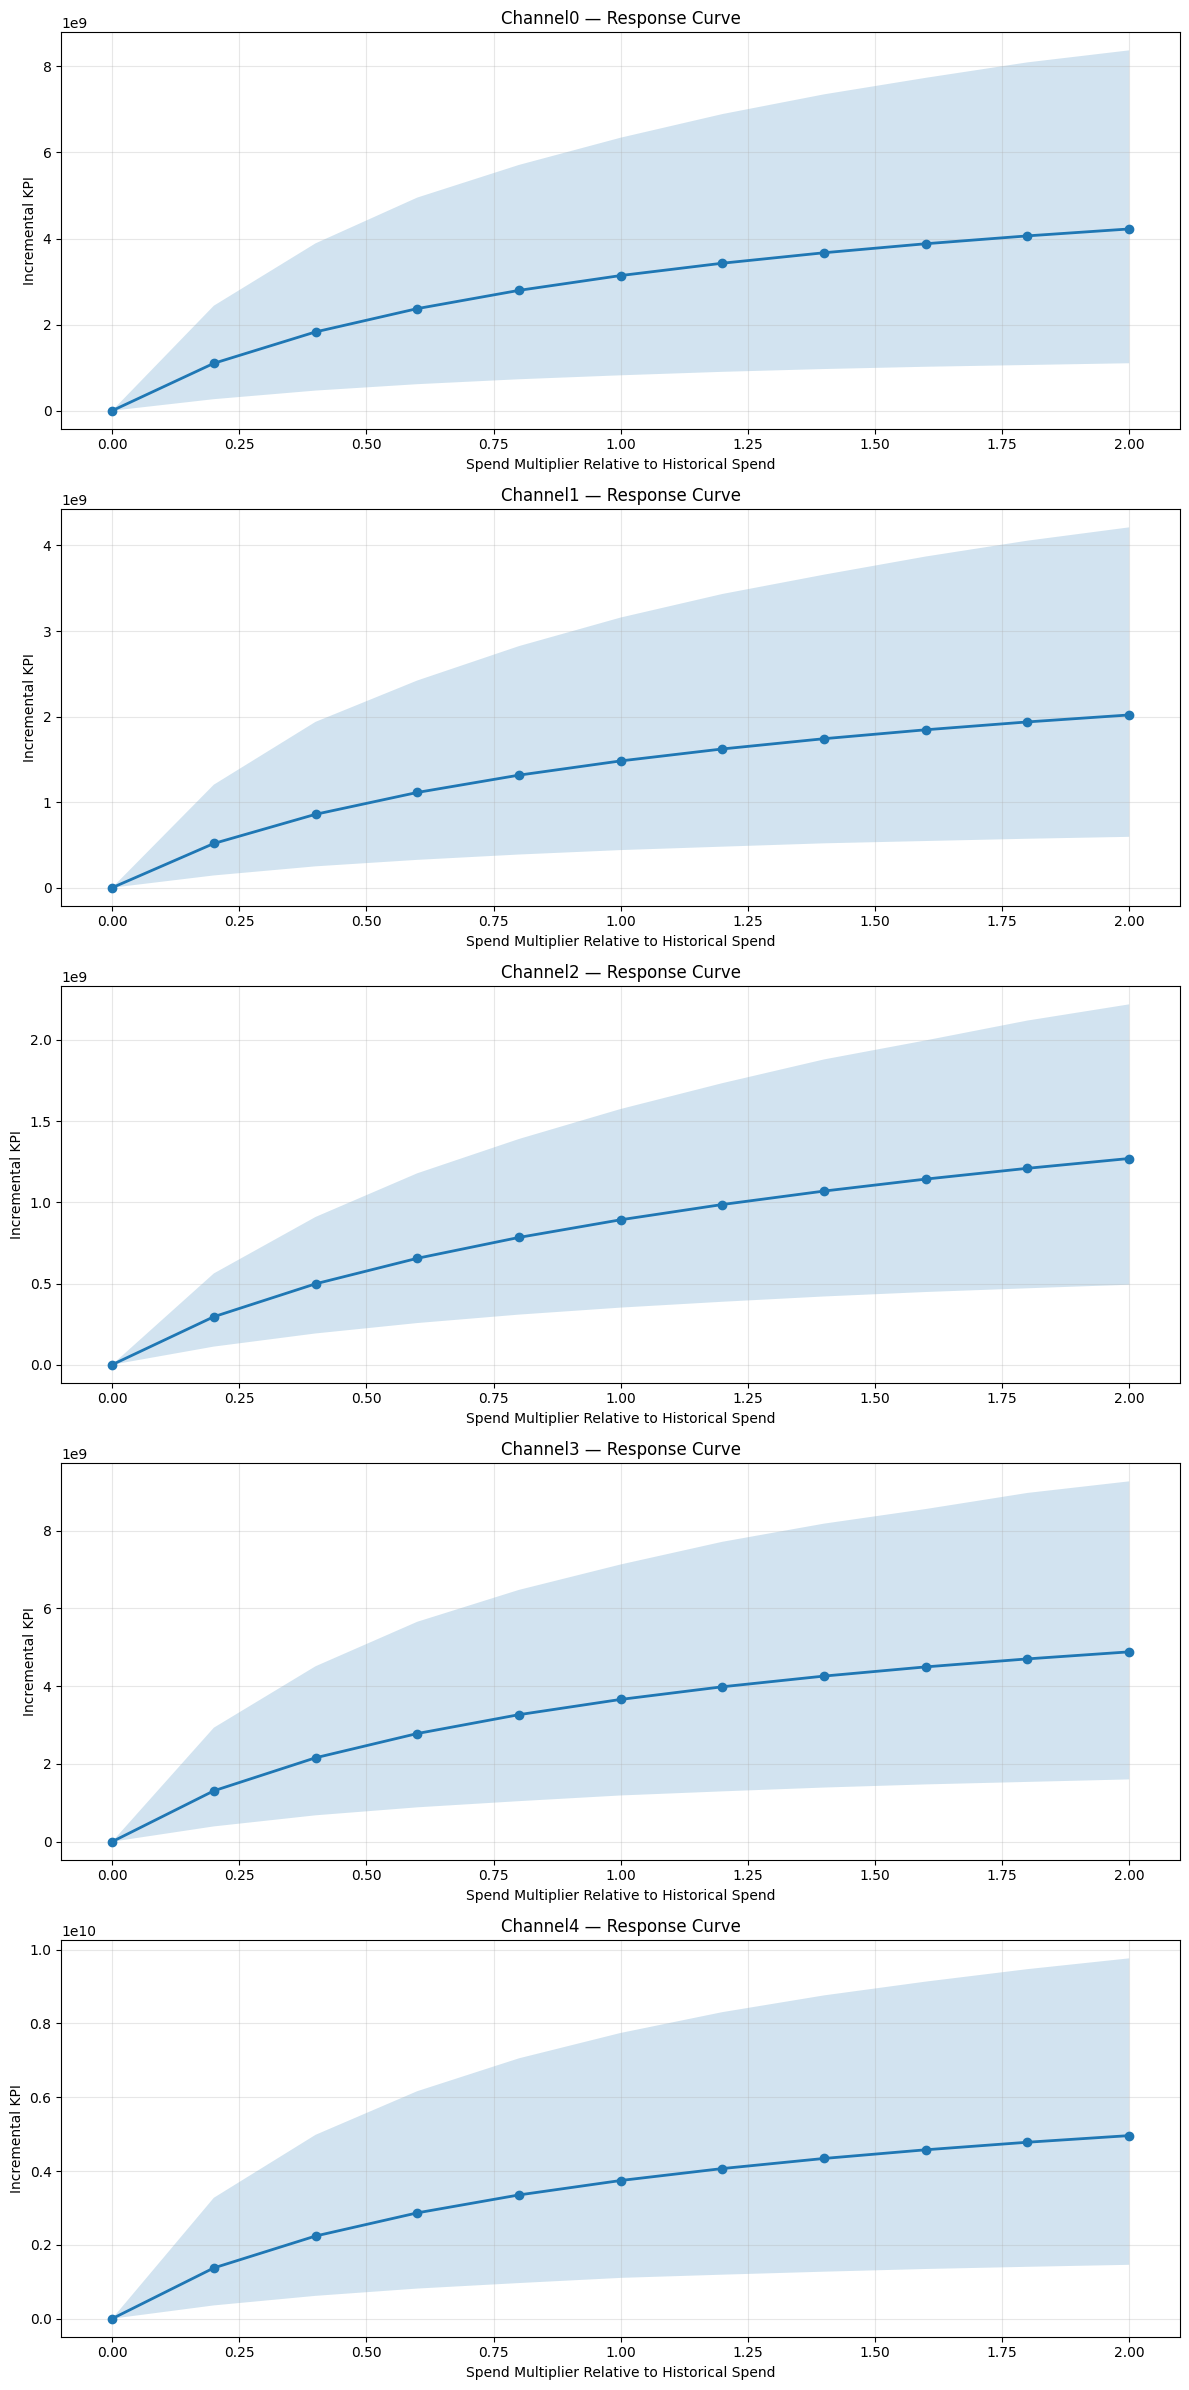


[6/7] Creating saturation summary...

Saturation summary:


,Channel,Historical_Spend,Historical_Incremental_KPI,Maximum_Incremental_KPI_0_to_2x,Initial_Marginal_Response,Final_Marginal_Response,Marginal_Response_Decline_%
0,Channel0,"40,501,713.08","3,140,250,975.83","4,222,860,618.67",135.958576,19.850707,85.40%
1,Channel1,"31,320,298.20","1,481,685,300.81","2,018,972,449.70",82.507126,13.013729,84.23%
2,Channel2,"12,079,349.34","892,513,904.56","1,269,938,946.27",122.311595,24.984285,79.57%
3,Channel3,"87,860,358.25","3,659,701,431.12","4,883,412,026.65",74.503902,10.298844,86.18%
4,Channel4,"47,730,683.48","3,744,659,502.75","4,961,453,377.02",144.124428,18.830159,86.93%



[7/7] Saving Step 11 results...

✓ Saved files:
  meridian_response_curves.csv
  meridian_marginal_response.csv
  meridian_saturation_summary.csv

STEP 11 COMPLETE

Spend range:
0.0× to 2.0× historical spend

Number of channels:
5

Number of spend scenarios:
11

Confidence level:
0.9

Next:
STEP 12 — BUDGET OPTIMIZATION & SCENARIO PLANNING


In [47]:
# =====================================================================
# STEP 11 — COMPLETE RESPONSE CURVES & SATURATION ANALYSIS
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

print("=" * 75)
print("STEP 11 — RESPONSE CURVES & SATURATION ANALYSIS")
print("=" * 75)


# ---------------------------------------------------------------------
# 1. CALCULATE RESPONSE CURVES
# ---------------------------------------------------------------------

print("\n[1/7] Calculating Meridian posterior response curves...")

response_result = analyzer_obj.response_curves(
    use_posterior=True,
    use_kpi=True
)

print("✓ Response curves calculated.")


# ---------------------------------------------------------------------
# 2. EXTRACT MERIDIAN DATASET
# ---------------------------------------------------------------------

print("\n[2/7] Extracting response-curve components...")

spend_multiplier = response_result["spend_multiplier"].values
channels = response_result["channel"].values
metrics = response_result["metric"].values

spend = response_result["spend"].values

incremental_outcome = response_result[
    "incremental_outcome"
].values

print("\nSpend multipliers:")
print(spend_multiplier)

print("\nChannels:")
print(channels)

print("\nMetrics:")
print(metrics)

print("\nSpend array shape:")
print(spend.shape)

print("\nIncremental outcome shape:")
print(incremental_outcome.shape)


# ---------------------------------------------------------------------
# 3. CREATE COMPLETE RESPONSE TABLE
# ---------------------------------------------------------------------

print("\n[3/7] Creating response-curve table...")

response_rows = []

for multiplier_index, multiplier in enumerate(spend_multiplier):

    for channel_index, channel in enumerate(channels):

        response_rows.append({

            "Channel":
                channel,

            "Spend_Multiplier":
                multiplier,

            "Spend":
                spend[
                    multiplier_index,
                    channel_index
                ],

            "Incremental_KPI_Mean":
                incremental_outcome[
                    multiplier_index,
                    channel_index,
                    0
                ],

            "Incremental_KPI_CI90_Lower":
                incremental_outcome[
                    multiplier_index,
                    channel_index,
                    1
                ],

            "Incremental_KPI_CI90_Upper":
                incremental_outcome[
                    multiplier_index,
                    channel_index,
                    2
                ]
        })


response_df = pd.DataFrame(response_rows)


print("\nComplete response table:")

display(
    response_df.style.format({

        "Spend":
            "{:,.2f}",

        "Incremental_KPI_Mean":
            "{:,.2f}",

        "Incremental_KPI_CI90_Lower":
            "{:,.2f}",

        "Incremental_KPI_CI90_Upper":
            "{:,.2f}"
    })
)


# ---------------------------------------------------------------------
# 4. CALCULATE MARGINAL RESPONSE BETWEEN SPEND LEVELS
# ---------------------------------------------------------------------

print("\n[4/7] Calculating marginal response between spend levels...")

marginal_rows = []

for channel in channels:

    channel_data = response_df[
        response_df["Channel"] == channel
    ].sort_values(
        "Spend_Multiplier"
    ).reset_index(drop=True)

    for i in range(1, len(channel_data)):

        previous = channel_data.iloc[i - 1]

        current = channel_data.iloc[i]

        spend_change = (
            current["Spend"]
            - previous["Spend"]
        )

        outcome_change = (
            current["Incremental_KPI_Mean"]
            - previous["Incremental_KPI_Mean"]
        )

        marginal_response = (
            outcome_change / spend_change
            if spend_change != 0
            else np.nan
        )

        marginal_rows.append({

            "Channel":
                channel,

            "Spend_Multiplier":
                current["Spend_Multiplier"],

            "Spend":
                current["Spend"],

            "Incremental_KPI":
                current["Incremental_KPI_Mean"],

            "Marginal_Response":
                marginal_response
        })


marginal_df = pd.DataFrame(marginal_rows)


print("\nMarginal response table:")

display(
    marginal_df.style.format({

        "Spend":
            "{:,.2f}",

        "Incremental_KPI":
            "{:,.2f}",

        "Marginal_Response":
            "{:.6f}"
    })
)


# ---------------------------------------------------------------------
# 5. PLOT RESPONSE CURVES
# ---------------------------------------------------------------------

print("\n[5/7] Generating response curves...")

fig, axes = plt.subplots(
    5,
    1,
    figsize=(12, 24)
)

for i, channel in enumerate(channels):

    data = response_df[
        response_df["Channel"] == channel
    ].sort_values(
        "Spend_Multiplier"
    )

    x = data["Spend_Multiplier"].values

    y = data["Incremental_KPI_Mean"].values

    lower = data["Incremental_KPI_CI90_Lower"].values

    upper = data["Incremental_KPI_CI90_Upper"].values

    axes[i].plot(
        x,
        y,
        marker="o",
        linewidth=2
    )

    axes[i].fill_between(
        x,
        lower,
        upper,
        alpha=0.20
    )

    axes[i].set_title(
        f"{channel} — Response Curve"
    )

    axes[i].set_xlabel(
        "Spend Multiplier Relative to Historical Spend"
    )

    axes[i].set_ylabel(
        "Incremental KPI"
    )

    axes[i].grid(
        alpha=0.3
    )


plt.tight_layout()

plt.show()


# ---------------------------------------------------------------------
# 6. CREATE SATURATION SUMMARY
# ---------------------------------------------------------------------

print("\n[6/7] Creating saturation summary...")

saturation_rows = []

for channel in channels:

    data = response_df[
        response_df["Channel"] == channel
    ].sort_values(
        "Spend_Multiplier"
    ).reset_index(drop=True)

    marginal_data = marginal_df[
        marginal_df["Channel"] == channel
    ].sort_values(
        "Spend_Multiplier"
    ).reset_index(drop=True)

    # Initial marginal response
    initial_marginal = (
        marginal_data["Marginal_Response"].iloc[0]
    )

    # Final marginal response
    final_marginal = (
        marginal_data["Marginal_Response"].iloc[-1]
    )

    # Percentage decline in marginal response
    marginal_decline = (
        1 -
        final_marginal / initial_marginal
    ) * 100

    # Maximum incremental outcome
    maximum_outcome = (
        data["Incremental_KPI_Mean"].max()
    )

    # Incremental outcome at historical spend
    historical_row = data[
        np.isclose(
            data["Spend_Multiplier"],
            1.0
        )
    ]

    if len(historical_row) > 0:

        historical_outcome = (
            historical_row[
                "Incremental_KPI_Mean"
            ].iloc[0]
        )

    else:

        historical_outcome = np.nan


    saturation_rows.append({

        "Channel":
            channel,

        "Historical_Spend":
            data[
                np.isclose(
                    data["Spend_Multiplier"],
                    1.0
                )
            ]["Spend"].iloc[0],

        "Historical_Incremental_KPI":
            historical_outcome,

        "Maximum_Incremental_KPI_0_to_2x":
            maximum_outcome,

        "Initial_Marginal_Response":
            initial_marginal,

        "Final_Marginal_Response":
            final_marginal,

        "Marginal_Response_Decline_%":
            marginal_decline
    })


saturation_summary = pd.DataFrame(
    saturation_rows
)


print("\nSaturation summary:")

display(
    saturation_summary.style.format({

        "Historical_Spend":
            "{:,.2f}",

        "Historical_Incremental_KPI":
            "{:,.2f}",

        "Maximum_Incremental_KPI_0_to_2x":
            "{:,.2f}",

        "Initial_Marginal_Response":
            "{:.6f}",

        "Final_Marginal_Response":
            "{:.6f}",

        "Marginal_Response_Decline_%":
            "{:.2f}%"
    })
)


# ---------------------------------------------------------------------
# 7. SAVE ALL RESULTS
# ---------------------------------------------------------------------

print("\n[7/7] Saving Step 11 results...")

response_df.to_csv(
    "meridian_response_curves.csv",
    index=False
)

marginal_df.to_csv(
    "meridian_marginal_response.csv",
    index=False
)

saturation_summary.to_csv(
    "meridian_saturation_summary.csv",
    index=False
)

print("\n✓ Saved files:")

print("  meridian_response_curves.csv")
print("  meridian_marginal_response.csv")
print("  meridian_saturation_summary.csv")


# ---------------------------------------------------------------------
# FINAL SUMMARY
# ---------------------------------------------------------------------

print("\n" + "=" * 75)
print("STEP 11 COMPLETE")
print("=" * 75)

print("\nSpend range:")
print(
    f"{spend_multiplier.min():.1f}× "
    f"to "
    f"{spend_multiplier.max():.1f}× historical spend"
)

print("\nNumber of channels:")
print(len(channels))

print("\nNumber of spend scenarios:")
print(len(spend_multiplier))

print("\nConfidence level:")
print(
    response_result.attrs.get(
        "confidence_level",
        "Not specified"
    )
)

print("\nNext:")
print("STEP 12 — BUDGET OPTIMIZATION & SCENARIO PLANNING")

print("=" * 75)

In [57]:
# =====================================================================
# STEP 12 — MERIDIAN BUDGET OPTIMIZATION
# FAST / EXPLORATORY VERSION
# =====================================================================

import numpy as np
import pandas as pd
from IPython.display import display
from meridian.analysis import optimizer

print("=" * 80)
print("STEP 12 — MERIDIAN BUDGET OPTIMIZATION")
print("=" * 80)


# ---------------------------------------------------------------------
# 1. HISTORICAL CHANNEL SPEND
# ---------------------------------------------------------------------

print("\n[1/8] Calculating historical budget...")

channel_spend = {
    "Channel0": 40501713.08,
    "Channel1": 31320298.20,
    "Channel2": 12079349.34,
    "Channel3": 87860358.25,
    "Channel4": 47730683.48,
}

channels = list(channel_spend.keys())

historical_total_budget = sum(channel_spend.values())

historical_pct = np.array([
    channel_spend[ch] / historical_total_budget
    for ch in channels
])

print("\nHistorical allocation:")

for ch, spend, pct in zip(
    channels,
    channel_spend.values(),
    historical_pct
):
    print(
        f"  {ch}: "
        f"${spend:,.2f} "
        f"({pct * 100:.2f}%)"
    )

print(
    f"\nHistorical total budget: "
    f"${historical_total_budget:,.2f}"
)

print(
    f"Allocation sum: "
    f"{historical_pct.sum():.6f}"
)


# ---------------------------------------------------------------------
# 2. VERIFY POSTERIOR SIZE
# ---------------------------------------------------------------------

print("\n[2/8] Checking posterior size...")

posterior = mmm.inference_data.posterior

original_chains = posterior.sizes["chain"]
original_draws = posterior.sizes["draw"]

print(f"Original chains: {original_chains}")
print(f"Original draws per chain: {original_draws}")
print(
    f"Original total posterior draws: "
    f"{original_chains * original_draws:,}"
)


# ---------------------------------------------------------------------
# 3. THIN POSTERIOR FOR EXPLORATORY OPTIMIZATION
# ---------------------------------------------------------------------

print("\n[3/8] Thinning posterior for optimization...")

# Keep 15% of posterior draws per chain.
# This is ONLY for exploratory optimization.
# The full posterior will be restored after optimization.

mmm.posterior_thinning(
    sampling_rate=0.15,
    preserve_original=True,
)

thinned_posterior = mmm.inference_data.posterior

thinned_chains = thinned_posterior.sizes["chain"]
thinned_draws = thinned_posterior.sizes["draw"]

print(
    f"Thinned chains: {thinned_chains}"
)

print(
    f"Thinned draws per chain: {thinned_draws}"
)

print(
    f"Thinned total draws: "
    f"{thinned_chains * thinned_draws:,}"
)


# ---------------------------------------------------------------------
# 4. CREATE BUDGET OPTIMIZER
# ---------------------------------------------------------------------

print("\n[4/8] Creating BudgetOptimizer...")

budget_optimizer = optimizer.BudgetOptimizer(mmm)

print("✓ BudgetOptimizer created.")


# ---------------------------------------------------------------------
# 5. RUN FIXED-BUDGET OPTIMIZATION
# ---------------------------------------------------------------------

print("\n[5/8] Running fixed-budget optimization...")

print("\nOptimization scenario:")
print(f"  Total budget = ${historical_total_budget:,.2f}")
print("  Budget type = Fixed")
print("  Objective = Maximize modeled KPI")
print("  KPI = Conversions")
print("  Posterior = Thinned exploratory posterior")
print("  Lower constraint = 30%")
print("  Upper constraint = 30%")
print("  Geographies = All")
print("  Time period = Full modeling period")


optimization_results = budget_optimizer.optimize(
    use_posterior=True,

    fixed_budget=True,

    budget=historical_total_budget,

    pct_of_spend=historical_pct.tolist(),

    spend_constraint_lower=0.30,

    spend_constraint_upper=0.30,

    use_kpi=True,

    confidence_level=0.90,

    batch_size=50,
)


print("\n✓ Budget optimization completed.")


# ---------------------------------------------------------------------
# 6. INSPECT OPTIMIZATION RESULT
# ---------------------------------------------------------------------

print("\n[6/8] Inspecting optimization result...")

print(
    "\nResult object type:"
)

print(
    type(optimization_results)
)

if hasattr(
    optimization_results,
    "optimized"
):

    print("\nOptimized allocation:")
    print(
        optimization_results.optimized
    )

if hasattr(
    optimization_results,
    "non_optimized"
):

    print("\nNon-optimized allocation:")
    print(
        optimization_results.non_optimized
    )


# ---------------------------------------------------------------------
# 7. CONVERT RESULT INTO A TABLE
# ---------------------------------------------------------------------

print("\n[7/8] Creating allocation comparison table...")

# OptimizationResults normally exposes the underlying xarray dataset.
# Try common result representations.

result_dataset = None

if hasattr(
    optimization_results,
    "optimization_results"
):

    result_dataset = (
        optimization_results.optimization_results
    )

elif hasattr(
    optimization_results,
    "data"
):

    result_dataset = optimization_results.data


if result_dataset is not None:

    print(
        "\nOptimization dataset:"
    )

    print(
        result_dataset
    )


# ---------------------------------------------------------------------
# 8. RESTORE FULL POSTERIOR
# ---------------------------------------------------------------------

print("\n[8/8] Restoring full posterior...")

mmm.restore_full_posterior()

restored_posterior = (
    mmm.inference_data.posterior
)

print(
    f"Restored chains: "
    f"{restored_posterior.sizes['chain']}"
)

print(
    f"Restored draws per chain: "
    f"{restored_posterior.sizes['draw']}"
)

print(
    f"Restored total draws: "
    f"{restored_posterior.sizes['chain'] * restored_posterior.sizes['draw']:,}"
)


# ---------------------------------------------------------------------
# SAVE BASIC HISTORICAL ALLOCATION
# ---------------------------------------------------------------------

historical_table = pd.DataFrame({
    "channel": channels,
    "historical_spend": [
        channel_spend[ch]
        for ch in channels
    ],
    "historical_pct": historical_pct * 100,
})

historical_table.to_csv(
    "meridian_historical_budget_allocation.csv",
    index=False
)


# ---------------------------------------------------------------------
# FINAL
# ---------------------------------------------------------------------

print("\n" + "=" * 80)
print("STEP 12 — BUDGET OPTIMIZATION FINISHED")
print("=" * 80)

print(
    "\nHistorical total budget:"
)

print(
    f"${historical_total_budget:,.2f}"
)

print(
    "\nThe full posterior has been restored."
)

print(
    "\nNext step:"
)

print(
    "Compare historical allocation with optimized allocation."
)

print("=" * 80)

STEP 12 — MERIDIAN BUDGET OPTIMIZATION

[1/8] Calculating historical budget...

Historical allocation:
  Channel0: $40,501,713.08 (18.45%)
  Channel1: $31,320,298.20 (14.27%)
  Channel2: $12,079,349.34 (5.50%)
  Channel3: $87,860,358.25 (40.03%)
  Channel4: $47,730,683.48 (21.75%)

Historical total budget: $219,492,402.35
Allocation sum: 1.000000

[2/8] Checking posterior size...
Original chains: 4
Original draws per chain: 1000
Original total posterior draws: 4,000

[3/8] Thinning posterior for optimization...
Thinned chains: 4
Thinned draws per chain: 150
Thinned total draws: 600

[4/8] Creating BudgetOptimizer...
✓ BudgetOptimizer created.

[5/8] Running fixed-budget optimization...

Optimization scenario:
  Total budget = $219,492,402.35
  Budget type = Fixed
  Objective = Maximize modeled KPI
  KPI = Conversions
  Posterior = Thinned exploratory posterior
  Lower constraint = 30%
  Upper constraint = 30%
  Geographies = All
  Time period = Full modeling period

✓ Budget optimizati

In [58]:
# =====================================================================
# STEP 12B — EXTRACT & COMPARE OPTIMIZED BUDGET
# =====================================================================

import numpy as np
import pandas as pd
from IPython.display import display, HTML

print("=" * 80)
print("STEP 12B — OPTIMIZATION RESULTS")
print("=" * 80)


# ---------------------------------------------------------------------
# 1. CHECK OPTIMIZATION RESULT OBJECT
# ---------------------------------------------------------------------

print("\n[1/6] Checking OptimizationResults object...")

print(
    "Object:",
    type(optimization_results)
)

print("\nAvailable public attributes:")

public_attributes = [
    x for x in dir(optimization_results)
    if not x.startswith("_")
]

print(public_attributes)


# ---------------------------------------------------------------------
# 2. EXTRACT NON-OPTIMIZED DATA
# ---------------------------------------------------------------------

print("\n[2/6] Extracting non-optimized data...")

nonoptimized_data = optimization_results.nonoptimized_data

print(
    "\nNon-optimized data type:",
    type(nonoptimized_data)
)

print("\nNon-optimized dataset:")
print(nonoptimized_data)

print(
    "\nNon-optimized variables:"
)

print(
    list(nonoptimized_data.data_vars)
)


# ---------------------------------------------------------------------
# 3. EXTRACT OPTIMIZED DATA
# ---------------------------------------------------------------------

print("\n[3/6] Extracting optimized data...")

optimized_data = optimization_results.optimized_data

print(
    "\nOptimized data type:",
    type(optimized_data)
)

print("\nOptimized dataset:")
print(optimized_data)

print(
    "\nOptimized variables:"
)

print(
    list(optimized_data.data_vars)
)


# ---------------------------------------------------------------------
# 4. CONVERT TO DATAFRAMES
# ---------------------------------------------------------------------

print("\n[4/6] Creating comparison tables...")

nonopt_df = (
    nonoptimized_data
    .to_dataframe()
    .reset_index()
)

opt_df = (
    optimized_data
    .to_dataframe()
    .reset_index()
)

print("\nNon-optimized table:")
display(nonopt_df)

print("\nOptimized table:")
display(opt_df)


# ---------------------------------------------------------------------
# 5. CREATE CHANNEL-LEVEL COMPARISON
# ---------------------------------------------------------------------

print("\n[5/6] Building historical vs optimized comparison...")

# Identify the channel column automatically
possible_channel_columns = [
    "channel",
    "media",
    "paid_media"
]

channel_column = None

for col in possible_channel_columns:
    if col in opt_df.columns:
        channel_column = col
        break

if channel_column is None:

    print(
        "\nCould not automatically identify the channel column."
    )

    print(
        "Available columns:"
    )

    print(
        opt_df.columns.tolist()
    )

else:

    print(
        f"\nChannel column detected: {channel_column}"
    )

    # Keep only channel-level rows
    comparison = pd.DataFrame()

    comparison["channel"] = (
        opt_df[channel_column]
        .astype(str)
    )

    # ---------------------------------------------------------------
    # Spend
    # ---------------------------------------------------------------

    if "spend" in nonopt_df.columns:

        comparison["historical_spend"] = (
            nonopt_df["spend"]
            .values
        )

    if "spend" in opt_df.columns:

        comparison["optimized_spend"] = (
            opt_df["spend"]
            .values
        )

    # ---------------------------------------------------------------
    # Percentage of spend
    # ---------------------------------------------------------------

    if "percentage_of_spend" in nonopt_df.columns:

        comparison["historical_pct"] = (
            nonopt_df["percentage_of_spend"]
            .values * 100
        )

    elif "pct_of_spend" in nonopt_df.columns:

        comparison["historical_pct"] = (
            nonopt_df["pct_of_spend"]
            .values * 100
        )

    if "percentage_of_spend" in opt_df.columns:

        comparison["optimized_pct"] = (
            opt_df["percentage_of_spend"]
            .values * 100
        )

    elif "pct_of_spend" in opt_df.columns:

        comparison["optimized_pct"] = (
            opt_df["pct_of_spend"]
            .values * 100
        )

    # ---------------------------------------------------------------
    # ROI
    # ---------------------------------------------------------------

    if "roi" in nonopt_df.columns:

        comparison["historical_roi"] = (
            nonopt_df["roi"]
            .values
        )

    if "roi" in opt_df.columns:

        comparison["optimized_roi"] = (
            opt_df["roi"]
            .values
        )

    # ---------------------------------------------------------------
    # mROI
    # ---------------------------------------------------------------

    if "mroi" in nonopt_df.columns:

        comparison["historical_mroi"] = (
            nonopt_df["mroi"]
            .values
        )

    if "mroi" in opt_df.columns:

        comparison["optimized_mroi"] = (
            opt_df["mroi"]
            .values
        )

    # ---------------------------------------------------------------
    # Incremental outcome
    # ---------------------------------------------------------------

    if "incremental_outcome" in nonopt_df.columns:

        comparison["historical_incremental_kpi"] = (
            nonopt_df["incremental_outcome"]
            .values
        )

    if "incremental_outcome" in opt_df.columns:

        comparison["optimized_incremental_kpi"] = (
            opt_df["incremental_outcome"]
            .values
        )

    # ---------------------------------------------------------------
    # Spend change
    # ---------------------------------------------------------------

    if (
        "historical_spend" in comparison.columns
        and
        "optimized_spend" in comparison.columns
    ):

        comparison["spend_change"] = (
            comparison["optimized_spend"]
            -
            comparison["historical_spend"]
        )

        comparison["spend_change_pct"] = (
            comparison["spend_change"]
            /
            comparison["historical_spend"]
            * 100
        )

    # ---------------------------------------------------------------
    # KPI change
    # ---------------------------------------------------------------

    if (
        "historical_incremental_kpi" in comparison.columns
        and
        "optimized_incremental_kpi" in comparison.columns
    ):

        comparison["kpi_change"] = (
            comparison["optimized_incremental_kpi"]
            -
            comparison["historical_incremental_kpi"]
        )

    # ---------------------------------------------------------------
    # Display
    # ---------------------------------------------------------------

    print(
        "\n=============================================================="
    )

    print(
        "HISTORICAL vs OPTIMIZED CHANNEL ALLOCATION"
    )

    print(
        "=============================================================="
    )

    display(
        comparison.round(4)
    )


# ---------------------------------------------------------------------
# 6. SAVE RESULTS + GENERATE HTML REPORT
# ---------------------------------------------------------------------

print("\n[6/6] Saving optimization outputs...")

# Save raw datasets
nonopt_df.to_csv(
    "meridian_nonoptimized_budget_results.csv",
    index=False
)

opt_df.to_csv(
    "meridian_optimized_budget_results.csv",
    index=False
)

if channel_column is not None:

    comparison.to_csv(
        "meridian_historical_vs_optimized_budget.csv",
        index=False
    )

# Generate Meridian's official HTML optimization report
try:

    optimization_results.output_optimization_summary(
        filename="meridian_budget_optimization_report.html",
        filepath="."
    )

    print(
        "\n✓ Meridian HTML report created:"
    )

    print(
        "  meridian_budget_optimization_report.html"
    )

except Exception as e:

    print(
        "\nHTML report generation issue:"
    )

    print(e)


print("\n" + "=" * 80)
print("STEP 12B COMPLETE")
print("=" * 80)

print("\nFiles created:")

print(
    "  1. meridian_nonoptimized_budget_results.csv"
)

print(
    "  2. meridian_optimized_budget_results.csv"
)

print(
    "  3. meridian_historical_vs_optimized_budget.csv"
)

print(
    "  4. meridian_budget_optimization_report.html"
)

print("\nNext: interpret the optimized allocation.")
print("=" * 80)

STEP 12B — OPTIMIZATION RESULTS

[1/6] Checking OptimizationResults object...
Object: <class 'meridian.analysis.optimizer.OptimizationResults'>

Available public attributes:
['analyzer', 'get_response_curves', 'meridian', 'new_data', 'nonoptimized_data', 'nonoptimized_data_with_optimal_freq', 'optimization_grid', 'optimized_data', 'output_optimization_summary', 'plot_budget_allocation', 'plot_incremental_outcome_delta', 'plot_response_curves', 'plot_spend_delta', 'spend_bounds', 'spend_ratio', 'template_env']

[2/6] Extracting non-optimized data...

Non-optimized data type: <class 'xarray.core.dataset.Dataset'>

Non-optimized dataset:
<xarray.Dataset> Size: 1kB
Dimensions:              (channel: 5, metric: 4)
Coordinates:
  * channel              (channel) object 40B 'Channel0' ... 'Channel4'
  * metric               (metric) <U6 96B 'mean' 'median' 'ci_lo' 'ci_hi'
Data variables:
    spend                (channel) float64 40B 4.05e+07 3.13e+07 ... 4.77e+07
    pct_of_spend         (ch

,channel,metric,spend,pct_of_spend,incremental_outcome,effectiveness,roi,mroi,cpik
0,Channel0,mean,40500000.0,0.184510,3.052020e+09,0.552583,75.358527,37.635817,0.019232
1,Channel0,median,40500000.0,0.184510,2.822068e+09,0.510949,69.680699,36.004514,0.014351
2,Channel0,ci_lo,40500000.0,0.184510,7.759388e+08,0.140488,19.158983,8.837545,0.006642
3,Channel0,ci_hi,40500000.0,0.184510,6.097921e+09,1.104058,150.565953,72.558205,0.052196
4,Channel1,mean,31300000.0,0.142597,1.479170e+09,0.455624,47.257813,24.119244,0.029887
5,Channel1,median,31300000.0,0.142597,1.308240e+09,0.402973,41.796809,21.404571,0.023925
6,Channel1,ci_lo,31300000.0,0.142597,4.547684e+08,0.140081,14.529341,6.570160,0.010415
7,Channel1,ci_hi,31300000.0,0.142597,3.005397e+09,0.925742,96.019084,51.503509,0.068827
8,Channel2,mean,12100000.0,0.055125,8.919194e+08,0.547751,73.712345,41.469862,0.016981
9,Channel2,median,12100000.0,0.055125,8.481008e+08,0.520841,70.090975,40.200047,0.014267



Optimized table:


,channel,metric,spend,pct_of_spend,incremental_outcome,effectiveness,roi,mroi,cpik
0,Channel0,mean,52600000.0,0.239636,3.455332e+09,0.481692,65.690728,29.274779,0.021986
1,Channel0,median,52600000.0,0.239636,3.257359e+09,0.454093,61.926974,27.860972,0.016148
2,Channel0,ci_lo,52600000.0,0.239636,8.835085e+08,0.123166,16.796740,6.146530,0.007660
3,Channel0,ci_hi,52600000.0,0.239636,6.867157e+09,0.957319,130.554318,57.889284,0.059536
4,Channel1,mean,26600000.0,0.121185,1.357457e+09,0.492013,51.032220,27.594185,0.027778
5,Channel1,median,26600000.0,0.121185,1.198587e+09,0.434431,45.059653,24.448443,0.022193
6,Channel1,ci_lo,26600000.0,0.121185,4.097971e+08,0.148532,15.405906,7.676355,0.009437
7,Channel1,ci_hi,26600000.0,0.121185,2.818776e+09,1.021672,105.969040,57.880989,0.064911
8,Channel2,mean,15700000.0,0.071526,1.027572e+09,0.486358,65.450477,34.068261,0.019104
9,Channel2,median,15700000.0,0.071526,9.795033e+08,0.463606,62.388747,32.933407,0.016029



[5/6] Building historical vs optimized comparison...

Channel column detected: channel

HISTORICAL vs OPTIMIZED CHANNEL ALLOCATION


,channel,historical_spend,optimized_spend,historical_pct,optimized_pct,historical_roi,optimized_roi,historical_mroi,optimized_mroi,historical_incremental_kpi,optimized_incremental_kpi,spend_change,spend_change_pct,kpi_change
0,Channel0,40500000.0,52600000.0,18.4510,23.9636,75.3585,65.6907,37.6358,29.2748,3.052020e+09,3.455332e+09,12100000.0,29.8765,4.033119e+08
1,Channel0,40500000.0,52600000.0,18.4510,23.9636,69.6807,61.9270,36.0045,27.8610,2.822068e+09,3.257359e+09,12100000.0,29.8765,4.352905e+08
2,Channel0,40500000.0,52600000.0,18.4510,23.9636,19.1590,16.7967,8.8375,6.1465,7.759388e+08,8.835085e+08,12100000.0,29.8765,1.075697e+08
3,Channel0,40500000.0,52600000.0,18.4510,23.9636,150.5660,130.5543,72.5582,57.8893,6.097921e+09,6.867157e+09,12100000.0,29.8765,7.692361e+08
4,Channel1,31300000.0,26600000.0,14.2597,12.1185,47.2578,51.0322,24.1192,27.5942,1.479170e+09,1.357457e+09,-4700000.0,-15.0160,-1.217125e+08
5,Channel1,31300000.0,26600000.0,14.2597,12.1185,41.7968,45.0597,21.4046,24.4484,1.308240e+09,1.198587e+09,-4700000.0,-15.0160,-1.096534e+08
6,Channel1,31300000.0,26600000.0,14.2597,12.1185,14.5293,15.4059,6.5702,7.6764,4.547684e+08,4.097971e+08,-4700000.0,-15.0160,-4.497125e+07
7,Channel1,31300000.0,26600000.0,14.2597,12.1185,96.0191,105.9690,51.5035,57.8810,3.005397e+09,2.818776e+09,-4700000.0,-15.0160,-1.866208e+08
8,Channel2,12100000.0,15700000.0,5.5125,7.1526,73.7123,65.4505,41.4699,34.0683,8.919194e+08,1.027572e+09,3600000.0,29.7521,1.356531e+08
9,Channel2,12100000.0,15700000.0,5.5125,7.1526,70.0910,62.3887,40.2000,32.9334,8.481008e+08,9.795033e+08,3600000.0,29.7521,1.314025e+08



[6/6] Saving optimization outputs...

✓ Meridian HTML report created:
  meridian_budget_optimization_report.html

STEP 12B COMPLETE

Files created:
  1. meridian_nonoptimized_budget_results.csv
  2. meridian_optimized_budget_results.csv
  3. meridian_historical_vs_optimized_budget.csv
  4. meridian_budget_optimization_report.html

Next: interpret the optimized allocation.


In [59]:
# =====================================================================
# STEP 12C — CORRECT CHANNEL-LEVEL OPTIMIZATION SUMMARY
# =====================================================================

import numpy as np
import pandas as pd
from IPython.display import display

print("=" * 80)
print("STEP 12C — CORRECTED OPTIMIZATION SUMMARY")
print("=" * 80)


# ---------------------------------------------------------------------
# 1. INSPECT OPTIMIZED DATA DIMENSIONS
# ---------------------------------------------------------------------

print("\n[1/7] Inspecting optimization dimensions...")

print("\nOptimized data dimensions:")
print(optimized_data.dims)

print("\nOptimized coordinates:")
for coord in optimized_data.coords:
    print(
        f"  {coord}: "
        f"{optimized_data.coords[coord].values}"
    )


# ---------------------------------------------------------------------
# 2. CONVERT TO DATAFRAME
# ---------------------------------------------------------------------

print("\n[2/7] Converting optimization data...")

opt_df = (
    optimized_data
    .to_dataframe()
    .reset_index()
)

nonopt_df = (
    nonoptimized_data
    .to_dataframe()
    .reset_index()
)

print("\nOptimized columns:")
print(opt_df.columns.tolist())


# ---------------------------------------------------------------------
# 3. IDENTIFY CHANNEL COLUMN
# ---------------------------------------------------------------------

channel_col = "channel"

channels = (
    opt_df[channel_col]
    .unique()
    .tolist()
)

print("\nChannels:")
print(channels)


# ---------------------------------------------------------------------
# 4. AGGREGATE POSTERIOR DIMENSIONS
# ---------------------------------------------------------------------

print("\n[3/7] Aggregating posterior results by channel...")

# Identify columns that represent posterior/sample dimensions.
# We retain channel and average everything else that varies across
# posterior/chain observations.

id_columns = [channel_col]

numeric_columns = [
    col
    for col in opt_df.columns
    if col not in id_columns
    and pd.api.types.is_numeric_dtype(opt_df[col])
]

# These are the variables we want summarized.
summary_variables = [
    col
    for col in [
        "spend",
        "percentage_of_spend",
        "pct_of_spend",
        "roi",
        "mroi",
        "incremental_outcome",
        "cpik",
        "effectiveness",
    ]
    if col in opt_df.columns
]

print("\nVariables available for summary:")
print(summary_variables)


# ---------------------------------------------------------------------
# 5. SUMMARIZE OPTIMIZED RESULTS
# ---------------------------------------------------------------------

optimized_summary = (
    opt_df
    .groupby(channel_col, sort=False)[summary_variables]
    .mean()
    .reset_index()
)

# Rename percentage variable if necessary
if "percentage_of_spend" in optimized_summary.columns:

    optimized_summary["optimized_pct"] = (
        optimized_summary["percentage_of_spend"] * 100
    )

elif "pct_of_spend" in optimized_summary.columns:

    optimized_summary["optimized_pct"] = (
        optimized_summary["pct_of_spend"] * 100
    )


# ---------------------------------------------------------------------
# 6. SUMMARIZE NON-OPTIMIZED RESULTS
# ---------------------------------------------------------------------

nonoptimized_summary = (
    nonopt_df
    .groupby(channel_col, sort=False)[
        [
            col
            for col in [
                "spend",
                "percentage_of_spend",
                "pct_of_spend",
                "roi",
                "mroi",
                "incremental_outcome",
                "cpik",
                "effectiveness",
            ]
            if col in nonopt_df.columns
        ]
    ]
    .mean()
    .reset_index()
)

if "percentage_of_spend" in nonoptimized_summary.columns:

    nonoptimized_summary["historical_pct"] = (
        nonoptimized_summary["percentage_of_spend"] * 100
    )

elif "pct_of_spend" in nonoptimized_summary.columns:

    nonoptimized_summary["historical_pct"] = (
        nonoptimized_summary["pct_of_spend"] * 100
    )


# ---------------------------------------------------------------------
# 7. BUILD FINAL CHANNEL-LEVEL TABLE
# ---------------------------------------------------------------------

print("\n[4/7] Building final channel-level comparison...")

final_summary = pd.DataFrame({
    "channel": channels
})


# Historical spend
hist_spend_map = dict(
    zip(
        nonoptimized_summary[channel_col],
        nonoptimized_summary["spend"]
    )
)

opt_spend_map = dict(
    zip(
        optimized_summary[channel_col],
        optimized_summary["spend"]
    )
)

final_summary["historical_spend"] = (
    final_summary["channel"]
    .map(hist_spend_map)
)

final_summary["optimized_spend"] = (
    final_summary["channel"]
    .map(opt_spend_map)
)


# Historical and optimized percentages
if "historical_pct" in nonoptimized_summary.columns:

    hist_pct_map = dict(
        zip(
            nonoptimized_summary[channel_col],
            nonoptimized_summary["historical_pct"]
        )
    )

    final_summary["historical_pct"] = (
        final_summary["channel"]
        .map(hist_pct_map)
    )


if "optimized_pct" in optimized_summary.columns:

    opt_pct_map = dict(
        zip(
            optimized_summary[channel_col],
            optimized_summary["optimized_pct"]
        )
    )

    final_summary["optimized_pct"] = (
        final_summary["channel"]
        .map(opt_pct_map)
    )


# ROI
if "roi" in nonoptimized_summary.columns:

    final_summary["historical_roi"] = (
        final_summary["channel"]
        .map(
            dict(
                zip(
                    nonoptimized_summary[channel_col],
                    nonoptimized_summary["roi"]
                )
            )
        )
    )

if "roi" in optimized_summary.columns:

    final_summary["optimized_roi"] = (
        final_summary["channel"]
        .map(
            dict(
                zip(
                    optimized_summary[channel_col],
                    optimized_summary["roi"]
                )
            )
        )
    )


# mROI
if "mroi" in nonoptimized_summary.columns:

    final_summary["historical_mroi"] = (
        final_summary["channel"]
        .map(
            dict(
                zip(
                    nonoptimized_summary[channel_col],
                    nonoptimized_summary["mroi"]
                )
            )
        )
    )

if "mroi" in optimized_summary.columns:

    final_summary["optimized_mroi"] = (
        final_summary["channel"]
        .map(
            dict(
                zip(
                    optimized_summary[channel_col],
                    optimized_summary["mroi"]
                )
            )
        )
    )


# Incremental KPI
if "incremental_outcome" in nonoptimized_summary.columns:

    final_summary["historical_incremental_kpi"] = (
        final_summary["channel"]
        .map(
            dict(
                zip(
                    nonoptimized_summary[channel_col],
                    nonoptimized_summary["incremental_outcome"]
                )
            )
        )
    )

if "incremental_outcome" in optimized_summary.columns:

    final_summary["optimized_incremental_kpi"] = (
        final_summary["channel"]
        .map(
            dict(
                zip(
                    optimized_summary[channel_col],
                    optimized_summary["incremental_outcome"]
                )
            )
        )
    )


# ---------------------------------------------------------------------
# 8. CALCULATE CHANGES
# ---------------------------------------------------------------------

print("\n[5/7] Calculating allocation changes...")

final_summary["spend_change"] = (
    final_summary["optimized_spend"]
    -
    final_summary["historical_spend"]
)

final_summary["spend_change_pct"] = (
    final_summary["spend_change"]
    /
    final_summary["historical_spend"]
    * 100
)


if (
    "historical_incremental_kpi" in final_summary.columns
    and
    "optimized_incremental_kpi" in final_summary.columns
):

    final_summary["kpi_change"] = (
        final_summary["optimized_incremental_kpi"]
        -
        final_summary["historical_incremental_kpi"]
    )

    final_summary["kpi_change_pct"] = (
        final_summary["kpi_change"]
        /
        final_summary["historical_incremental_kpi"]
        * 100
    )


# ---------------------------------------------------------------------
# 9. DISPLAY FINAL TABLE
# ---------------------------------------------------------------------

print("\n[6/7] Final channel-level optimization table")

display(
    final_summary.round(4)
)


# ---------------------------------------------------------------------
# 10. BUDGET CHECK
# ---------------------------------------------------------------------

print("\n[7/7] Budget consistency check...")

historical_sum = (
    final_summary["historical_spend"]
    .sum()
)

optimized_sum = (
    final_summary["optimized_spend"]
    .sum()
)

print(
    f"\nHistorical total: "
    f"${historical_sum:,.2f}"
)

print(
    f"Optimized total: "
    f"${optimized_sum:,.2f}"
)

print(
    f"Difference: "
    f"${optimized_sum - historical_sum:,.2f}"
)

print(
    "\nHistorical allocation sum:"
)

print(
    f"{final_summary['historical_pct'].sum():.4f}%"
)

print(
    "\nOptimized allocation sum:"
)

print(
    f"{final_summary['optimized_pct'].sum():.4f}%"
)


# ---------------------------------------------------------------------
# 11. SAVE CLEAN RESULT
# ---------------------------------------------------------------------

final_summary.to_csv(
    "meridian_final_budget_optimization_summary.csv",
    index=False
)

print(
    "\n✓ Saved:"
)

print(
    "  meridian_final_budget_optimization_summary.csv"
)

print("\n" + "=" * 80)
print("STEP 12C COMPLETE")
print("=" * 80)

STEP 12C — CORRECTED OPTIMIZATION SUMMARY

[1/7] Inspecting optimization dimensions...

Optimized data dimensions:
FrozenMappingWarningOnValuesAccess({'channel': 5, 'metric': 4})

Optimized coordinates:
  channel: ['Channel0' 'Channel1' 'Channel2' 'Channel3' 'Channel4']
  metric: ['mean' 'median' 'ci_lo' 'ci_hi']

[2/7] Converting optimization data...

Optimized columns:
['channel', 'metric', 'spend', 'pct_of_spend', 'incremental_outcome', 'effectiveness', 'roi', 'mroi', 'cpik']

Channels:
['Channel0', 'Channel1', 'Channel2', 'Channel3', 'Channel4']

[3/7] Aggregating posterior results by channel...

Variables available for summary:
['spend', 'pct_of_spend', 'roi', 'mroi', 'incremental_outcome', 'cpik', 'effectiveness']

[4/7] Building final channel-level comparison...

[5/7] Calculating allocation changes...

[6/7] Final channel-level optimization table


,channel,historical_spend,optimized_spend,historical_pct,optimized_pct,historical_roi,optimized_roi,historical_mroi,optimized_mroi,historical_incremental_kpi,optimized_incremental_kpi,spend_change,spend_change_pct,kpi_change,kpi_change_pct
0,Channel0,40500000.0,52600000.0,18.4510,23.9636,78.6910,68.7422,38.7590,30.2929,3.186987e+09,3.615839e+09,12100000.0,29.8765,4.288521e+08,13.4563
1,Channel1,31300000.0,26600000.0,14.2597,12.1185,49.9008,54.3667,25.8994,29.4000,1.561894e+09,1.446154e+09,-4700000.0,-15.0160,-1.157395e+08,-7.4102
2,Channel2,12100000.0,15700000.0,5.5125,7.1526,75.1002,66.2211,42.5250,34.9823,9.087126e+08,1.039671e+09,3600000.0,29.7521,1.309579e+08,14.4114
3,Channel3,87900000.0,62700000.0,40.0456,28.5649,44.5841,52.9631,21.6145,28.7421,3.918942e+09,3.320789e+09,-25200000.0,-28.6689,-5.981537e+08,-15.2631
4,Channel4,47700000.0,61900000.0,21.7312,28.2005,82.2895,70.6808,37.4462,28.7584,3.925208e+09,4.375143e+09,14200000.0,29.7694,4.499357e+08,11.4627



[7/7] Budget consistency check...

Historical total: $219,500,000.00
Optimized total: $219,500,000.00
Difference: $0.00

Historical allocation sum:
100.0000%

Optimized allocation sum:
100.0000%

✓ Saved:
  meridian_final_budget_optimization_summary.csv

STEP 12C COMPLETE


In [61]:
# =====================================================================
# STEP 12D — BUDGET CONSTRAINT SENSITIVITY ANALYSIS
# =====================================================================

import numpy as np
import pandas as pd
from IPython.display import display
from meridian.analysis import optimizer

print("=" * 85)
print("STEP 12D — BUDGET CONSTRAINT SENSITIVITY ANALYSIS")
print("=" * 85)


# ---------------------------------------------------------------------
# 1. BASIC SETTINGS
# ---------------------------------------------------------------------

print("\n[1/8] Setting up sensitivity analysis...")

channel_spend = {
    "Channel0": 40501713.08,
    "Channel1": 31320298.20,
    "Channel2": 12079349.34,
    "Channel3": 87860358.25,
    "Channel4": 47730683.48,
}

channels = list(channel_spend.keys())

historical_total_budget = sum(channel_spend.values())

historical_pct = np.array([
    channel_spend[ch] / historical_total_budget
    for ch in channels
])

constraint_scenarios = [0.20, 0.30, 0.50]

print(
    f"\nFixed total budget: "
    f"${historical_total_budget:,.2f}"
)

print(
    "\nScenarios:"
)

for c in constraint_scenarios:
    print(
        f"  ±{int(c * 100)}%"
    )


# ---------------------------------------------------------------------
# 2. CHECK FULL POSTERIOR
# ---------------------------------------------------------------------

print("\n[2/8] Checking full posterior...")

full_chains = mmm.inference_data.posterior.sizes["chain"]
full_draws = mmm.inference_data.posterior.sizes["draw"]

print(
    f"Full posterior: "
    f"{full_chains} chains × {full_draws} draws"
)

print(
    f"Total draws: "
    f"{full_chains * full_draws:,}"
)


# ---------------------------------------------------------------------
# 3. THIN POSTERIOR FOR SENSITIVITY ANALYSIS
# ---------------------------------------------------------------------

print("\n[3/8] Thinning posterior for sensitivity analysis...")

mmm.posterior_thinning(
    sampling_rate=0.15,
    preserve_original=True,
)

thin_chains = mmm.inference_data.posterior.sizes["chain"]
thin_draws = mmm.inference_data.posterior.sizes["draw"]

print(
    f"Thinned posterior: "
    f"{thin_chains} chains × {thin_draws} draws"
)

print(
    f"Total optimization draws: "
    f"{thin_chains * thin_draws:,}"
)


# ---------------------------------------------------------------------
# 4. FUNCTION TO RUN ONE SCENARIO
# ---------------------------------------------------------------------

def run_budget_scenario(constraint):

    print("\n" + "-" * 75)

    print(
        f"Running ±{int(constraint * 100)}% scenario..."
    )

    print("-" * 75)

    budget_optimizer = optimizer.BudgetOptimizer(mmm)

    result = budget_optimizer.optimize(
        use_posterior=True,
        fixed_budget=True,
        budget=historical_total_budget,
        pct_of_spend=historical_pct.tolist(),
        spend_constraint_lower=constraint,
        spend_constraint_upper=constraint,
        use_kpi=True,
        confidence_level=0.90,
        batch_size=50,
    )

    print(
        f"✓ ±{int(constraint * 100)}% optimization completed."
    )

    return result


# ---------------------------------------------------------------------
# 5. RUN ALL THREE SCENARIOS
# ---------------------------------------------------------------------

print("\n[4/8] Running optimization scenarios...")

scenario_results = {}

try:

    for constraint in constraint_scenarios:

        scenario_results[constraint] = (
            run_budget_scenario(constraint)
        )

except Exception as e:

    print(
        "\nERROR during sensitivity analysis:"
    )

    print(e)

    # Restore full posterior before stopping
    try:
        mmm.restore_full_posterior()
        print(
            "\nFull posterior restored after error."
        )
    except Exception:
        pass

    raise


# ---------------------------------------------------------------------
# 6. EXTRACT CHANNEL-LEVEL RESULTS
# ---------------------------------------------------------------------

print("\n[5/8] Extracting channel-level results...")


def summarize_optimization(result, constraint):

    # ---------------------------------------------------------------
    # Optimized data
    # ---------------------------------------------------------------

    opt_df = (
        result.optimized_data
        .to_dataframe()
        .reset_index()
    )

    nonopt_df = (
        result.nonoptimized_data
        .to_dataframe()
        .reset_index()
    )

    # ---------------------------------------------------------------
    # Aggregate posterior dimensions by channel
    # ---------------------------------------------------------------

    opt_grouped = (
        opt_df
        .groupby("channel", sort=False)
        .mean(numeric_only=True)
        .reset_index()
    )

    nonopt_grouped = (
        nonopt_df
        .groupby("channel", sort=False)
        .mean(numeric_only=True)
        .reset_index()
    )

    # ---------------------------------------------------------------
    # Build channel-level table
    # ---------------------------------------------------------------

    table = pd.DataFrame({
        "channel": channels
    })

    # Historical spend
    historical_map = dict(
        zip(
            nonopt_grouped["channel"],
            nonopt_grouped["spend"]
        )
    )

    optimized_map = dict(
        zip(
            opt_grouped["channel"],
            opt_grouped["spend"]
        )
    )

    table["historical_spend"] = (
        table["channel"]
        .map(historical_map)
    )

    table["optimized_spend"] = (
        table["channel"]
        .map(optimized_map)
    )

    # ---------------------------------------------------------------
    # Percentage allocation
    # ---------------------------------------------------------------

    table["historical_pct"] = (
        table["historical_spend"]
        /
        historical_total_budget
        *
        100
    )

    table["optimized_pct"] = (
        table["optimized_spend"]
        /
        table["optimized_spend"].sum()
        *
        100
    )

    # ---------------------------------------------------------------
    # Spend change
    # ---------------------------------------------------------------

    table["spend_change"] = (
        table["optimized_spend"]
        -
        table["historical_spend"]
    )

    table["spend_change_pct"] = (
        table["spend_change"]
        /
        table["historical_spend"]
        *
        100
    )

    # ---------------------------------------------------------------
    # ROI
    # ---------------------------------------------------------------

    if "roi" in nonopt_grouped.columns:

        table["historical_roi"] = (
            table["channel"]
            .map(
                dict(
                    zip(
                        nonopt_grouped["channel"],
                        nonopt_grouped["roi"]
                    )
                )
            )
        )

    if "roi" in opt_grouped.columns:

        table["optimized_roi"] = (
            table["channel"]
            .map(
                dict(
                    zip(
                        opt_grouped["channel"],
                        opt_grouped["roi"]
                    )
                )
            )
        )

    # ---------------------------------------------------------------
    # mROI
    # ---------------------------------------------------------------

    if "mroi" in nonopt_grouped.columns:

        table["historical_mroi"] = (
            table["channel"]
            .map(
                dict(
                    zip(
                        nonopt_grouped["channel"],
                        nonopt_grouped["mroi"]
                    )
                )
            )
        )

    if "mroi" in opt_grouped.columns:

        table["optimized_mroi"] = (
            table["channel"]
            .map(
                dict(
                    zip(
                        opt_grouped["channel"],
                        opt_grouped["mroi"]
                    )
                )
            )
        )

    # ---------------------------------------------------------------
    # Incremental KPI
    # ---------------------------------------------------------------

    if "incremental_outcome" in nonopt_grouped.columns:

        table["historical_incremental_kpi"] = (
            table["channel"]
            .map(
                dict(
                    zip(
                        nonopt_grouped["channel"],
                        nonopt_grouped["incremental_outcome"]
                    )
                )
            )
        )

    if "incremental_outcome" in opt_grouped.columns:

        table["optimized_incremental_kpi"] = (
            table["channel"]
            .map(
                dict(
                    zip(
                        opt_grouped["channel"],
                        opt_grouped["incremental_outcome"]
                    )
                )
            )
        )

    # ---------------------------------------------------------------
    # KPI change
    # ---------------------------------------------------------------

    if (
        "historical_incremental_kpi" in table.columns
        and
        "optimized_incremental_kpi" in table.columns
    ):

        table["kpi_change"] = (
            table["optimized_incremental_kpi"]
            -
            table["historical_incremental_kpi"]
        )

        table["kpi_change_pct"] = (
            table["kpi_change"]
            /
            table["historical_incremental_kpi"]
            *
            100
        )

    # ---------------------------------------------------------------
    # Add scenario label
    # ---------------------------------------------------------------

    table["constraint"] = (
        f"±{int(constraint * 100)}%"
    )

    # Put constraint first
    columns_order = [
        "constraint",
        "channel",
        "historical_spend",
        "optimized_spend",
        "historical_pct",
        "optimized_pct",
        "spend_change",
        "spend_change_pct",
    ]

    remaining = [
        col
        for col in table.columns
        if col not in columns_order
    ]

    table = table[
        columns_order + remaining
    ]

    return table


# Create tables
scenario_tables = {}

for constraint, result in scenario_results.items():

    scenario_tables[constraint] = (
        summarize_optimization(
            result,
            constraint
        )
    )


# ---------------------------------------------------------------------
# 7. CREATE SCENARIO SUMMARY
# ---------------------------------------------------------------------

print("\n[6/8] Creating scenario-level summary...")


scenario_summary_rows = []


for constraint, table in scenario_tables.items():

    total_optimized_kpi = np.nan

    total_historical_kpi = np.nan

    if "optimized_incremental_kpi" in table.columns:

        total_optimized_kpi = (
            table["optimized_incremental_kpi"]
            .sum()
        )

    if "historical_incremental_kpi" in table.columns:

        total_historical_kpi = (
            table["historical_incremental_kpi"]
            .sum()
        )

    kpi_change = (
        total_optimized_kpi
        -
        total_historical_kpi
    )

    kpi_change_pct = (
        kpi_change
        /
        total_historical_kpi
        *
        100
    )

    total_optimized_spend = (
        table["optimized_spend"]
        .sum()
    )

    scenario_summary_rows.append({

        "constraint": f"±{int(constraint * 100)}%",

        "total_budget":
            total_optimized_spend,

        "historical_incremental_kpi":
            total_historical_kpi,

        "optimized_incremental_kpi":
            total_optimized_kpi,

        "kpi_change":
            kpi_change,

        "kpi_change_pct":
            kpi_change_pct,

    })


scenario_summary = pd.DataFrame(
    scenario_summary_rows
)


# ---------------------------------------------------------------------
# 8. DISPLAY RESULTS AND SAVE
# ---------------------------------------------------------------------

print("\n[7/8] Displaying sensitivity results...")


print("\n" + "=" * 85)

print(
    "SCENARIO-LEVEL SENSITIVITY SUMMARY"
)

print("=" * 85)

display(
    scenario_summary.round(4)
)


print("\n" + "=" * 85)

print(
    "CHANNEL ALLOCATION — ±20%"
)

print("=" * 85)

display(
    scenario_tables[0.20].round(4)
)


print("\n" + "=" * 85)

print(
    "CHANNEL ALLOCATION — ±30%"
)

print("=" * 85)

display(
    scenario_tables[0.30].round(4)
)


print("\n" + "=" * 85)

print(
    "CHANNEL ALLOCATION — ±50%"
)

print("=" * 85)

display(
    scenario_tables[0.50].round(4)
)


# ---------------------------------------------------------------------
# SAVE FILES
# ---------------------------------------------------------------------

print("\n[8/8] Saving sensitivity analysis...")


scenario_summary.to_csv(
    "meridian_budget_constraint_sensitivity_summary.csv",
    index=False
)


for constraint, table in scenario_tables.items():

    pct = int(constraint * 100)

    table.to_csv(
        f"meridian_budget_optimization_pm{pct}.csv",
        index=False
    )


# Combined channel-level dataset
all_scenarios = pd.concat(
    scenario_tables.values(),
    ignore_index=True
)

all_scenarios.to_csv(
    "meridian_budget_constraint_sensitivity_channels.csv",
    index=False
)


# ---------------------------------------------------------------------
# RESTORE FULL POSTERIOR
# ---------------------------------------------------------------------

print("\nRestoring full posterior...")

mmm.restore_full_posterior()

restored_chains = (
    mmm.inference_data.posterior.sizes["chain"]
)

restored_draws = (
    mmm.inference_data.posterior.sizes["draw"]
)

print(
    f"Restored posterior: "
    f"{restored_chains} chains × "
    f"{restored_draws} draws"
)

print(
    f"Total restored draws: "
    f"{restored_chains * restored_draws:,}"
)


# ---------------------------------------------------------------------
# FINAL
# ---------------------------------------------------------------------

print("\n" + "=" * 85)

print(
    "STEP 12D — CONSTRAINT SENSITIVITY COMPLETE"
)

print("=" * 85)

print("\nFiles created:")

print(
    "  meridian_budget_constraint_sensitivity_summary.csv"
)

print(
    "  meridian_budget_constraint_sensitivity_channels.csv"
)

print(
    "  meridian_budget_optimization_pm20.csv"
)

print(
    "  meridian_budget_optimization_pm30.csv"
)

print(
    "  meridian_budget_optimization_pm50.csv"
)

print(
    "\nFull 4,000-draw posterior restored."
)

print("=" * 85)

STEP 12D — BUDGET CONSTRAINT SENSITIVITY ANALYSIS

[1/8] Setting up sensitivity analysis...

Fixed total budget: $219,492,402.35

Scenarios:
  ±20%
  ±30%
  ±50%

[2/8] Checking full posterior...
Full posterior: 4 chains × 1000 draws
Total draws: 4,000

[3/8] Thinning posterior for sensitivity analysis...
Thinned posterior: 4 chains × 150 draws
Total optimization draws: 600

[4/8] Running optimization scenarios...

---------------------------------------------------------------------------
Running ±20% scenario...
---------------------------------------------------------------------------
✓ ±20% optimization completed.

---------------------------------------------------------------------------
Running ±30% scenario...
---------------------------------------------------------------------------
✓ ±30% optimization completed.

---------------------------------------------------------------------------
Running ±50% scenario...
--------------------------------------------------------------

,constraint,total_budget,historical_incremental_kpi,optimized_incremental_kpi,kpi_change,kpi_change_pct
0,±20%,219500000.0,1.357748e+10,1.385227e+10,2.747931e+08,2.0239
1,±30%,219500000.0,1.357748e+10,1.391484e+10,3.373611e+08,2.4847
2,±50%,219500000.0,1.357748e+10,1.394205e+10,3.645714e+08,2.6851



CHANNEL ALLOCATION — ±20%


,constraint,channel,historical_spend,optimized_spend,historical_pct,optimized_pct,spend_change,spend_change_pct,historical_roi,optimized_roi,historical_mroi,optimized_mroi,historical_incremental_kpi,optimized_incremental_kpi,kpi_change,kpi_change_pct
0,±20%,Channel0,40500000.0,48600000.0,18.4517,22.1412,8100000.0,20.0000,80.1688,73.1304,41.1109,34.6476,3.246837e+09,3.554139e+09,3.073022e+08,9.4647
1,±20%,Channel1,31300000.0,28600000.0,14.2602,13.0296,-2700000.0,-8.6262,47.8139,49.8821,24.9657,27.1616,1.496576e+09,1.426628e+09,-6.994872e+07,-4.6739
2,±20%,Channel2,12100000.0,14500000.0,5.5127,6.6059,2400000.0,19.8347,76.2408,70.1721,42.6204,37.2589,9.225138e+08,1.017496e+09,9.498172e+07,10.2960
3,±20%,Channel3,87900000.0,70600000.0,40.0469,32.1640,-17300000.0,-19.6815,43.7023,48.9528,20.8784,25.2484,3.841429e+09,3.456065e+09,-3.853648e+08,-10.0318
4,±20%,Channel4,47700000.0,57200000.0,21.7320,26.0592,9500000.0,19.9161,85.3276,76.8872,38.4410,32.4267,4.070124e+09,4.397947e+09,3.278227e+08,8.0544



CHANNEL ALLOCATION — ±30%


,constraint,channel,historical_spend,optimized_spend,historical_pct,optimized_pct,spend_change,spend_change_pct,historical_roi,optimized_roi,historical_mroi,optimized_mroi,historical_incremental_kpi,optimized_incremental_kpi,kpi_change,kpi_change_pct
0,±30%,Channel0,40500000.0,52600000.0,18.4517,23.9636,12100000.0,29.8765,80.1688,69.9978,41.1109,31.9549,3.246837e+09,3.681883e+09,4.350466e+08,13.3991
1,±30%,Channel1,31300000.0,25600000.0,14.2602,11.6629,-5700000.0,-18.2109,47.8139,52.6114,24.9657,29.4555,1.496576e+09,1.346851e+09,-1.497254e+08,-10.0045
2,±30%,Channel2,12100000.0,15700000.0,5.5127,7.1526,3600000.0,29.7521,76.2408,67.4331,42.6204,35.0897,9.225138e+08,1.058699e+09,1.361855e+08,14.7624
3,±30%,Channel3,87900000.0,63600000.0,40.0469,28.9749,-24300000.0,-27.6451,43.7023,51.5010,20.8784,27.5128,3.841429e+09,3.275462e+09,-5.659673e+08,-14.7332
4,±30%,Channel4,47700000.0,62000000.0,21.7320,28.2460,14300000.0,29.9790,85.3276,73.4185,38.4410,29.8269,4.070124e+09,4.551946e+09,4.818217e+08,11.8380



CHANNEL ALLOCATION — ±50%


,constraint,channel,historical_spend,optimized_spend,historical_pct,optimized_pct,spend_change,spend_change_pct,historical_roi,optimized_roi,historical_mroi,optimized_mroi,historical_incremental_kpi,optimized_incremental_kpi,kpi_change,kpi_change_pct
0,±50%,Channel0,40500000.0,55500000.0,18.4517,25.2847,15000000.0,37.0370,80.1688,67.8963,41.1109,30.3010,3.246837e+09,3.768244e+09,5.214071e+08,16.0589
1,±50%,Channel1,31300000.0,23700000.0,14.2602,10.7973,-7600000.0,-24.2812,47.8139,54.7162,24.9657,31.2292,1.496576e+09,1.296774e+09,-1.998028e+08,-13.3507
2,±50%,Channel2,12100000.0,18200000.0,5.5127,8.2916,6100000.0,50.4132,76.2408,62.2221,42.6204,31.0033,9.225138e+08,1.132442e+09,2.099286e+08,22.7561
3,±50%,Channel3,87900000.0,59000000.0,40.0469,26.8793,-28900000.0,-32.8783,43.7023,53.6459,20.8784,29.2758,3.841429e+09,3.165110e+09,-6.763190e+08,-17.6059
4,±50%,Channel4,47700000.0,63100000.0,21.7320,28.7472,15400000.0,32.2851,85.3276,72.5750,38.4410,29.3135,4.070124e+09,4.579482e+09,5.093574e+08,12.5145



[8/8] Saving sensitivity analysis...

Restoring full posterior...
Restored posterior: 4 chains × 1000 draws
Total restored draws: 4,000

STEP 12D — CONSTRAINT SENSITIVITY COMPLETE

Files created:
  meridian_budget_constraint_sensitivity_summary.csv
  meridian_budget_constraint_sensitivity_channels.csv
  meridian_budget_optimization_pm20.csv
  meridian_budget_optimization_pm30.csv
  meridian_budget_optimization_pm50.csv

Full 4,000-draw posterior restored.
